# Q-FLARE - Quantum Optimization Core (Colab notebook)

Standalone, single-engine QAOA validation of Q-FLARE flood-response resource
allocation. This notebook is the executable form of
`q_flare_quantum_core.py`: same code, same order, same results.

## How to run in Google Colab

1. Open the notebook and select **Runtime -> Run all**.
2. The first code cell installs the quantum stack (this can take a minute on a
   cold runtime), so the first run is slower than the rest.
3. The pipeline then executes top to bottom: input, validation, QUBO, exact
   classical baseline, QAOA circuit, angle optimization, statevector check,
   measurement, decoding, feasibility, comparison, 13 automated tests, saved
   artifacts and the final validation report.

## What you get

Artifacts are written to `q_flare_quantum_results/` in the runtime working
directory (downloaded automatically if you enable `FILES.save` in Colab):

| File | Contents |
| --- | --- |
| `classical_results.csv` | Exact brute-force baseline for every assignment |
| `quantum_measurements.csv` | Every measured bitstring with energy and feasibility |
| `comparison.csv` | Classical optimum vs QAOA best |
| `qaoa_distribution.png` | Ideal vs measured probability distribution |
| `final_report.json` | Machine-readable structured validation report |

## Using your own data (optional)

The notebook runs on built-in synthetic data by default. To supply a JSON file,
upload it and point the loader at it, or set the environment variable:

```python
bundle = load_demo_data("/content/my_locations.json")
result = main()
```

```python
import os
os.environ["QFLARE_INPUT_JSON"] = "/content/my_locations.json"
```

JSON schema: `rescue_teams` (int) and `locations` (non-empty list of objects with
`location_id`, `name`, `affected_population`, `urgency`; `latitude` and
`longitude` are optional).

## Scope and honesty

* This is a **local classical simulator** (`qiskit_aer.AerSimulator`), not a
  physical quantum computer.
* It does **not** prove quantum speedup or quantum superiority, and QAOA
  guarantees no optimality. A mismatch with the exact optimum is reported, not
  hidden.
* It does **not** touch the Q-FLARE frontend, backend, AI service, GIS service,
  databases or APIs. It is a closed experiment.

================================================================================
Q-FLARE - QUANTUM OPTIMIZATION CORE (STANDALONE SINGLE-FILE ENGINE)
================================================================================

PROJECT
-------
    Q-FLARE

FULL NAME
---------
    Quantum-AI Flood Forecasting and Disaster-Response
    Decision-Support Platform

PURPOSE OF THIS FILE
--------------------
    Standalone quantum optimization validation.

    This file implements and *demonstrates* the complete quantum resource
    allocation pipeline used by Q-FLARE to decide which flood-affected
    locations receive rescue resources first:

        Flood / resource data
            -> Input validation
            -> Problem definition
            -> Binary decision variables
            -> QUBO formulation
            -> QUBO validation
            -> Exact classical baseline
            -> QAOA circuit construction
            -> QAOA parameter optimization
            -> Quantum state simulation
            -> Quantum measurement
            -> Bitstring decoding
            -> Constraint / feasibility validation
            -> Classical vs quantum comparison
            -> Automated testing
            -> Final validation report

CURRENT STAGE
-------------
    Research / development / validation stage.

THIS FILE IS **NOT**
--------------------
    * The production Q-FLARE quantum service.
    * Connected to the Q-FLARE frontend.
    * Connected to the Q-FLARE backend.
    * Connected to the Q-FLARE AI service.
    * Connected to the Q-FLARE GIS service.
    * Connected to the Q-FLARE IoT service.
    * A replacement for the existing `quantum-service` folder.
    * A claim of quantum advantage or hardware supremacy.

THIS FILE **IS**
----------------
    A standalone experimental quantum engine used to validate the
    mathematical and quantum-computing logic BEFORE integration.

    Every result printed by this file is produced by real execution of the
    code in this file. No result is hard-coded, faked, or post-processed to
    make the quantum path look successful.

================================================================================
HOW TO RUN
================================================================================

    Google Colab:
        1. Open Google Colab.
        2. File -> Upload -> select `q_flare_quantum_core.py`.
        3. Open the uploaded file and click "Run" (or paste into a cell and run).
        4. Installation, implementation, tests, results and the final
           validation report are printed in order.

    Local machine / terminal:
        python q_flare_quantum_core.py

    The file executes top-to-bottom through `main()`.
    No other local Q-FLARE file is required, imported, or assumed.

================================================================================
QUANTUM CONCEPTS USED (short summary - full explanation is in the code)
================================================================================

QUBIT
    One qubit represents one binary decision variable.

        |0>  ->  this location is NOT selected for a rescue team
        |1>  ->  this location IS selected for a rescue team

BINARY DECISION VARIABLE
        x_i in {0, 1}

    For the demonstration problem:
        x_0 = L1 (Riverbank-A) selected?
        x_1 = L2 (Riverbank-B) selected?
        x_2 = L3 (Village-C)   selected?
        x_3 = L4 (Village-D)   selected?

QUBO (Quadratic Unconstrained Binary Optimization)
        E(x) = x^T Q x + offset

    QUBO is the standard bridge between constrained business problems and
    quantum optimizers. Because quantum optimizers such as QAOA minimize an
    *unconstrained* Hamiltonian, hard constraints (for example
    "number of assigned teams <= available teams") are encoded as
    *penalty terms* inside the cost function. A solution that violates the
    constraint is assigned a large energy and is therefore never preferred
    by the optimizer.

QAOA (Quantum Approximate Optimization Algorithm)
        |+>^n
            -> Cost Hamiltonian   exp(-i * gamma * H_C)
            -> Mixer Hamiltonian  exp(-i * 2 * beta * H_M)
            -> Layer 2
            -> ...
            -> Measurement

    p      = number of QAOA layers (circuit depth in variational parameters)
    gamma  = cost-Hamiltonian angle (controls the "how strongly do we
             punish bad solutions" behaviour)
    beta   = mixer-Hamiltonian angle (controls "how strongly do we move
             probability mass between |0> and |1> states")

QUANTUM SIMULATOR
    This implementation uses a **local classical simulator**
    (`qiskit_aer.AerSimulator` and `qiskit.quantum_info.Statevector`).

    This is **NOT** execution on a physical quantum computer.

    The purpose of the simulator is to validate the quantum algorithm
    (circuit construction, parameter binding, measurement statistics,
    decoding, feasibility handling) before any hardware execution.

================================================================================
SCIENTIFIC DISCLAIMER
================================================================================

    This experiment demonstrates and validates a QAOA-based optimization
    workflow on a small synthetic flood-response problem.

    It does NOT prove that quantum computing currently outperforms
    classical optimization for the real Q-FLARE problem.

    The simulator is not a physical quantum processor.

    Real-world Q-FLARE deployment requires:
        * real validated datasets
        * realistic constraints
        * scalability analysis
        * classical benchmark algorithms
        * noise analysis
        * hardware feasibility analysis
        * domain validation

    Unsupported claims that this file deliberately does NOT make:
        "quantum is faster", "quantum is better",
        "quantum guarantees optimality",
        "quantum will solve real floods faster".

    QAOA is probabilistic. The measured solution is reported exactly as the
    simulator produced it, including when it does not match the optimum.

================================================================================
REPRODUCIBILITY CONTRACT
================================================================================

    Every stochastic element is driven by an explicit, printed value:

        random seed (parameter initialization) : RANDOM_SEED
        simulator seed (sampling)              : RANDOM_SEED
        transpiler seed                        : RANDOM_SEED
        number of shots                        : MEASUREMENT_SHOTS
        QAOA depth (p)                         : P_DEPTH
        penalty coefficient (lambda)           : auto = total score + 1
        optimizer                              : SciPy COBYLA, N random restarts

    Re-running this file with the same values reproduces the same
    parameters, the same circuit, the same statevector and the same
    measurement counts.

================================================================================
PERFORMANCE NOTES
================================================================================

    The first demonstration is deliberately small so that it runs
    comfortably in Google Colab:

        4 qubits, QAOA depth p = 2, 4096 shots.

    Quantum simulation cost grows very quickly with the number of qubits:

        * a statevector of n qubits holds 2**n amplitudes
          (4 qubits -> 16 amplitudes, 20 qubits -> 1,048,576,
           30 qubits -> 1,073,741,824 amplitudes, i.e. not feasible on a
           notebook CPU);
        * an exact expectation value is a sum over 2**n basis states;
        * the QUBO matrix is dense-ish: n**2 coefficients;
        * sampling is comparatively cheap: O(shots x depth).

    This is exactly why the demonstration keeps n small, why the exact
    classical baseline is only practical for small n, and why a real
    Q-FLARE deployment would need an annealing device, a heuristic
    classical solver, or a circuit-cutting strategy.

================================================================================
STANDALONE GUARANTEES
================================================================================

    This file is a closed, self-contained experiment. It has:

        NO frontend connection
        NO backend connection
        NO database connection
        NO GitHub dependency
        NO existing Q-FLARE imports
        NO API calls
        NO external project files
        NO production credentials
        NO cloud credentials

    It only reads an optional JSON file that the user supplies explicitly.

## Preamble (imports and configuration)

In [1]:
# =============================================================================
# SECTION 0 - MODULE-LEVEL CONFIGURATION AND TYPE SUPPORT
# =============================================================================
#
# PURPOSE:
#     Central configuration for the whole file plus the small custom exception
#     types used for strict, non-silent failure handling.
#
# WHY:
#     A standalone research engine must be reproducible. Every stochastic
#     element (parameter initialization, simulator sampling) is driven by an
#     explicit seed declared in one place.
#
# FUTURE Q-FLARE USE:
#     These configuration values map to request-level options of the future
#     `/api/quantum/optimize` endpoint (e.g. `depth`, `shots`, `seed`).

from __future__ import annotations

import importlib
import sys
import warnings
from collections.abc import Callable, Sequence
from contextlib import contextmanager
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

# -----------------------------------------------------------------------------
# 0.1 - Global constants
# -----------------------------------------------------------------------------

# If True, the file installs its own dependencies via pip when they are
# missing. Set to False if the environment is managed externally
# (for example a pinned Colab runtime or a requirements.txt).
AUTO_INSTALL_DEPENDENCIES = True

# Version ranges that are known to work together for this pipeline.
# Qiskit 1.x and 2.x expose the same primitives used here
# (QuantumCircuit, PauliEvolutionGate, SparsePauliOp, Statevector, AerSimulator).
PINNED_REQUIREMENTS: tuple[str, ...] = (
    "qiskit>=1.2,<3.0",
    "qiskit-aer>=0.15",
    "numpy>=1.24",
    "pandas>=2.0",
    "scipy>=1.10",
    "matplotlib>=3.7",
)

# Third-party modules this file needs, mapped to their pip requirement name.
REQUIRED_MODULES: dict[str, str] = {
    "qiskit": "qiskit",
    "qiskit_aer": "qiskit-aer",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
}

# Name of the output directory created automatically by the run.
RESULTS_DIRECTORY_NAME = "q_flare_quantum_results"

# Files written into RESULTS_DIRECTORY_NAME.
RESULT_FILES: dict[str, str] = {
    "classical_csv": "classical_results.csv",
    "quantum_csv": "quantum_measurements.csv",
    "comparison_csv": "comparison.csv",
    "report_json": "final_report.json",
    "distribution_png": "qaoa_distribution.png",
}

# Optional user-supplied JSON input. When unset, the built-in synthetic
# demonstration dataset is used, so the program always runs standalone.
INPUT_JSON_ENV_VAR = "QFLARE_INPUT_JSON"

# Upper bound on the number of locations. The exact statevector expectation and
# the exhaustive classical baseline both scale as 2**n, so the demonstration is
# limited to small n. This is enforced instead of being discovered as an
# out-of-memory crash deep inside the simulator.
MAX_LOCATIONS = 12

# The quantum stack, imported once by `import_dependencies()` and reused by the
# version report. Deferred imports are required because the pip installer has
# to run before `import qiskit` on a cold Google Colab runtime.
_QUANTUM_STACK: dict[str, Any] = {}

# =============================================================================
# ERROR HANDLING POLICY
# =============================================================================
#
# WHAT:
#     Every failure mode of the pipeline has a dedicated exception type and a
#     stage name, and the stage context manager records the outcome.
#
# WHY:
#     A quantum pipeline fails in many different ways (missing packages, bad
#     data, impossible QUBO, unusable angles, empty measurements). A silent
#     failure would produce a plausible-looking but meaningless allocation, so
#     every error is reported with an explicit message and the original
#     exception is preserved as the cause.
#
# MAPPED FAILURE MODES
#     ImportError            -> QFlareDependencyError   (import_dependencies)
#     installation failure   -> QFlareDependencyError   (install_dependencies)
#     invalid input          -> QFlareValidationError   (validate_input)
#     QUBO construction      -> QFlareQuboError         (build_qubo_model)
#     QAOA circuit failure   -> QFlareCircuitError      (build_qaoa)
#     optimizer failure      -> QFlareOptimizerError    (optimize_qaoa)
#     simulator failure      -> QFlareSimulationError   (run_quantum_simulation)
#     measurement failure    -> QFlareSimulationError   (run_quantum_simulation)
#     decoder failure        -> QFlareDecodeError       (decode_solution)
#     any other error        -> QFlareStageError        (stage context manager)
#
# FORBIDDEN
#     A bare `except:` that swallows the error with a `pass` statement is never
#     used. Every `except` block either re-raises, records a failure, or reports
#     the problem and adapts explicitly.


class QFlareError(Exception):
    """Base class for every error raised by this standalone engine."""


class QFlareDependencyError(QFlareError):
    """
    Raised when a dependency cannot be imported or cannot be installed.

    Covers: ImportError handling and pip installation failure.
    """


class QFlareValidationError(QFlareError):
    """
    Raised when incoming flood/resource data is invalid.

    The engine NEVER silently repairs or coerces invalid input: it stops with
    an explicit, human-readable error message.
    """


class QFlareQuboError(QFlareError):
    """Raised when the QUBO cannot be constructed or is mathematically wrong."""


class QFlareCircuitError(QFlareError):
    """Raised when the QAOA circuit cannot be built or has the wrong shape."""


class QFlareOptimizerError(QFlareError):
    """Raised when the QAOA parameter search returns no usable result."""


class QFlareSimulationError(QFlareError):
    """Raised when the simulator fails to execute or returns no measurement."""


class QFlareDecodeError(QFlareError):
    """Raised when a measured bitstring cannot be decoded or is infeasible."""


class QFlareStageError(QFlareError):
    """
    Wraps any failure with the name of the pipeline stage that produced it.

    The original exception is always preserved as `__cause__`, so nothing is
    swallowed and the full traceback stays available.
    """

    def __init__(self, stage_name: str, cause: BaseException) -> None:
        super().__init__(
            f"STAGE FAILED [{stage_name}]: {type(cause).__name__}: {cause}"
        )
        self.stage_name = stage_name
        self.cause = cause


@dataclass
class StageStatus:
    """
    Outcome of one pipeline stage, used by the final terminal summary.

    Attributes:
        name: Stage label as printed in the final summary.
        passed: True when the stage completed without raising.
        detail: Human readable detail (or the failure message).
    """

    name: str
    passed: bool
    detail: str = ""


class StageRecorder:
    """
    Collects the outcome of every pipeline stage.

    WHY:
        The final report must state, stage by stage, what worked. Recording is
        done by the `stage` context manager, so a stage cannot be silently
        skipped: it is either recorded as PASS or as FAIL with its message.
    """

    def __init__(self) -> None:
        self.stages: list[StageStatus] = []

    def record(self, name: str, passed: bool, detail: str = "") -> None:
        """Record the outcome of a single stage."""
        self.stages.append(StageStatus(name=name, passed=passed, detail=detail))

    def status(self, name: str) -> str:
        """Return 'PASS', 'FAIL' or 'SKIPPED' for the final summary."""
        for stage in reversed(self.stages):
            if stage.name == name:
                return "PASS" if stage.passed else "FAIL"
        return "SKIPPED"

    @property
    def all_passed(self) -> bool:
        """True when every recorded stage passed."""
        return bool(self.stages) and all(stage.passed for stage in self.stages)


@contextmanager
def stage(name: str, recorder: StageRecorder):
    """
    Context manager that records a pipeline stage and re-raises its failure.

    Args:
        name: Stage name used in the final summary.
        recorder: Recorder receiving the outcome.

    Yields:
        None.

    Raises:
        QFlareStageError: For ANY exception raised inside the block, carrying
            the stage name and the original exception as its cause.
    """
    try:
        yield
    except QFlareStageError:
        raise
    except QFlareError as exc:
        recorder.record(name, False, str(exc))
        raise QFlareStageError(name, exc) from exc
    except Exception as exc:  # any unexpected error is reported, never hidden
        recorder.record(name, False, f"{type(exc).__name__}: {exc}")
        raise QFlareStageError(name, exc) from exc
    else:
        recorder.record(name, True)


# -----------------------------------------------------------------------------
# 0.2 - Engine configuration
# -----------------------------------------------------------------------------
#
# QUICK TUNING KNOBS
#     These are the values a user is most likely to change. They are declared
#     here, in one block, and used as the defaults of `QFlareConfig` so that a
#     change requires editing exactly one line - no other code has to be
#     touched, and nothing else in the file is aware of the values.
#
#         P_DEPTH          : number of QAOA layers (variational parameters = 2*p)
#         MEASUREMENT_SHOTS: measurement repetitions on the simulator
#         RANDOM_SEED      : seed for parameter init, transpiler and sampling
#         OPTIMIZER_RESTARTS: random restarts of the classical angle search
#         RESCUE_TEAMS      : rescue teams available (the hard constraint K)
#
#     Qiskit handles a few tens of qubits on a local simulator; the classical
#     brute-force baseline enumerates 2**n solutions, so the demonstration
#     dataset (n = 4, 16 solutions) is the intended operating range.

P_DEPTH = 2
MEASUREMENT_SHOTS = 4096
RANDOM_SEED = 42
OPTIMIZER_RESTARTS = 4
RESCUE_TEAMS = 2


@dataclass
class QFlareConfig:
    """
    Runtime configuration of the quantum engine.

    Attributes:
        qaoa_depth:
            Number of QAOA layers `p`. `p = 2` is the value used for the
            demonstration. Higher `p` gives a better expected energy but
            doubles the number of variational parameters per layer.
        shots:
            Number of measurement repetitions executed on the simulator.
            `4096` gives roughly 1.5% standard error on a probability of 0.5.
        seed:
            Master seed. Drives the AerSimulator sampling, the transpiler and
            the random initialization of the QAOA parameters, so the whole
            run is reproducible.
        optimizer_method:
            SciPy derivative-free method. COBYLA is the standard choice for
            shallow QAOA because the landscape is smooth but non-convex and
            noisy-free (exact statevector), and no analytic gradient is cheap.
        optimizer_maxiter:
            Maximum optimizer iterations per restart.
        optimizer_restarts:
            Number of random restarts. QAOA is non-convex; multi-start makes
            the reported result reproducible and gives the optimizer a fair
            chance of reaching the good basin.
        population_weight:
            Weight applied to normalized affected population inside the
            response score. `0.0` reproduces the pure urgency objective of the
            demonstration problem. Values `> 0` show how the real Q-FLARE
            objective (urgency + population impact) plugs into the SAME QUBO
            builder without changing any downstream code.
        penalty_weight:
            QUBO constraint penalty. `None` -> auto-computed from the data
            using a provably sufficient lower bound (see `auto_penalty_weight`).
        strict_draw_ascii:
            Force the ASCII circuit drawer. Useful on Windows consoles whose
            code page cannot render box-drawing characters.

    FUTURE Q-FLARE USE:
        An instance of this dataclass is the natural request payload of the
        future Q-FLARE quantum service.
    """

    qaoa_depth: int = P_DEPTH
    shots: int = MEASUREMENT_SHOTS
    seed: int = RANDOM_SEED
    optimizer_method: str = "COBYLA"
    optimizer_maxiter: int = 400
    optimizer_restarts: int = OPTIMIZER_RESTARTS
    population_weight: float = 0.0
    penalty_weight: int | None = None
    strict_draw_ascii: bool = False

## Section 1 - ENVIRONMENT SETUP

In [2]:
# =============================================================================
# SECTION 1 - ENVIRONMENT SETUP
# =============================================================================
#
# WHAT:
#     Print the program header, install missing dependencies with pip, import
#     the quantum stack, and display the verified environment versions.
#
# WHY:
#     This standalone file must work in a fresh Google Colab runtime where
#     nothing is guaranteed to be present. Installation is therefore
#     subprocess/pip based and executed at runtime, not at import time.
#
# HOW:
#     1. `install_dependencies()` probes each required module with `importlib`.
#     2. Missing modules trigger `subprocess.check_call([sys.executable, "-m",
#        "pip", "install", ...])`, which installs into the *current* kernel
#        (this is exactly what Colab requires - `!pip install` alone can
#        install into a different interpreter).
#     3. `import_dependencies()` imports the stack and raises
#        QFlareDependencyError on ImportError.
#     4. `display_environment()` prints the verified versions.
#
# Q-FLARE USE:
#     The same version banner should be emitted by the production
#     quantum-service on startup so that quantum runs are reproducible and
#     auditable.
#
# INPUT:
#     Nothing. The environment is inspected, never configured destructively.
#
# OUTPUT:
#     A verified `_QUANTUM_STACK` and a printed environment banner.
#
# DESIGN NOTE - DEFERRED IMPORTS:
#     Third-party modules are imported inside the functions that need them
#     instead of at the top of the file. This is required, not stylistic: the
#     installer above must run before `import qiskit`, and a module-level
#     import would crash the file on a cold Colab runtime.


def _print_banner(title: str, width: int = 60, char: str = "=") -> str:
    """
    Print a titled ASCII banner and return it as a string.

    Args:
        title: Banner title. An empty title prints a single separator line.
        width: Banner width in characters.
        char: Filler character.

    Returns:
        The banner string (also printed to stdout).
    """
    line = char * width
    banner = line if not title else f"{line}\n{title}\n{line}"
    print(banner)
    return banner


def print_header() -> None:
    """
    Print the Q-FLARE QUANTUM LAB program header.

    This is the first thing printed, so the reader immediately knows what is
    being executed and what the experiment is (and is not) allowed to claim.

    WHY THE DATA LINE IS NOT A CLAIM:
        The header is printed before the dataset is loaded, so it cannot know
        whether a user file was supplied. It therefore states the rule instead
        of asserting a fact; the resolved source is reported in the final
        report, in the final summary and in `final_report.json`.
    """
    border = "#" * 64
    print(border)
    print("Q-FLARE QUANTUM LAB")
    print("Quantum-AI Flood Forecasting and Disaster-Response Platform")
    print("Standalone quantum optimization validation engine")
    print(border)
    print("Project                : Q-FLARE")
    print("Experiment             : QAOA rescue-resource allocation")
    print("Data                   : SYNTHETIC demonstration data unless a user")
    print("                          JSON file is supplied (reported below)")
    print("Execution backend      : local AerSimulator (NOT a physical QPU)")
    print("Existing Q-FLARE code  : not imported, not modified, not required")
    print(border)


def _configure_stdout() -> None:
    """
    Make stdout tolerant of non-ASCII output.

    WHY:
        Qiskit's text circuit drawer emits box-drawing characters. On a
        Windows console with a legacy code page this raises UnicodeEncodeError
        and would abort the run. Colab already uses UTF-8, so this is a no-op
        there.

    ERROR HANDLING:
        A stream that cannot be reconfigured is reported, not ignored: the run
        continues (the quantum result is unaffected) but the limitation is
        printed so a truncated circuit drawing is never mistaken for a real
        rendering problem.
    """
    for stream in (sys.stdout, sys.stderr):
        reconfigure = getattr(stream, "reconfigure", None)
        if reconfigure is None:
            print(
                f"[setup] note: {getattr(stream, 'name', 'stream')} does not support "
                "reconfigure(); non-ASCII circuit output may be truncated."
            )
            continue
        try:
            reconfigure(encoding="utf-8", errors="replace")
        except (ValueError, OSError) as exc:
            print(
                f"[setup] note: could not switch "
                f"{getattr(stream, 'name', 'stream')} to UTF-8 ({exc}); "
                "non-ASCII circuit output may be truncated."
            )


def missing_dependencies() -> list[str]:
    """
    Return the pip requirement names of every module that is not importable.

    Returns:
        Sorted list of missing pip requirement strings (empty when the
        environment is already complete).
    """
    missing: list[str] = []
    for module_name, requirement in REQUIRED_MODULES.items():
        try:
            importlib.import_module(module_name)
        except ImportError as exc:
            # A missing dependency is data, not a crash: the caller decides
            # whether to install it. The reason is kept for the error message
            # raised later by install_dependencies().
            missing.append(requirement)
            print(f"[setup] import error for '{module_name}': {exc}")
    return sorted(missing)


def install_dependencies(force: bool = False) -> list[str]:
    """
    Install the required packages with pip when they are missing.

    Args:
        force: Reinstall even when every module already imports.

    Returns:
        The list of requirements that were requested from pip (empty when the
        environment was already complete and `force` is False).

    Raises:
        QFlareDependencyError: If pip fails, or if modules are still missing
            afterwards (typically a runtime restart is required on Colab).
    """
    import subprocess

    missing = [] if force else missing_dependencies()
    if not missing:
        print("[setup] All required Python packages are already importable.")
        return []

    print("[setup] Missing packages detected: " + ", ".join(missing))
    print("[setup] Installing with: " + " ".join(PINNED_REQUIREMENTS))
    print("[setup] (this can take a few minutes the first time)")

    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        *PINNED_REQUIREMENTS,
    ]
    try:
        subprocess.check_call(command)
    except subprocess.CalledProcessError as exc:  # pragma: no cover - env specific
        raise QFlareDependencyError(
            "pip installation failed. Install the dependencies manually with:\n"
            "  " + " ".join(command)
        ) from exc
    except OSError as exc:  # pragma: no cover - environment specific
        raise QFlareDependencyError(
            f"could not launch pip with '{command[0]}': {exc}"
        ) from exc

    importlib.invalidate_caches()
    still_missing = missing_dependencies()
    if still_missing:  # pragma: no cover - env specific
        raise QFlareDependencyError(
            "The following packages are still not importable after pip install: "
            + ", ".join(still_missing)
            + ".\nIn Google Colab: click Runtime -> Restart session, then run the "
            "file again."
        )
    return missing


def import_dependencies() -> dict[str, Any]:
    """
    Import the quantum stack once and cache it in `_QUANTUM_STACK`.

    WHY:
        The installer must run before `import qiskit` (a module-level import
        would crash a cold Colab runtime), but every later function still needs
        the modules. This function is the single, explicit import gate.

    Returns:
        Mapping of module name to imported module.

    Raises:
        QFlareDependencyError: If any required module cannot be imported.
    """
    if _QUANTUM_STACK:
        return _QUANTUM_STACK
    for module_name in REQUIRED_MODULES:
        try:
            _QUANTUM_STACK[module_name] = importlib.import_module(module_name)
        except ImportError as exc:
            raise QFlareDependencyError(
                f"required package '{module_name}' is not importable: {exc}\n"
                "Run the installer at the top of this file, then run it again."
            ) from exc
    return _QUANTUM_STACK


def environment_report() -> dict[str, str]:
    """
    Collect version information for the quantum environment.

    Uses the already-imported `_QUANTUM_STACK` when available, so the report
    reflects the modules the experiment actually ran with.

    Returns:
        Mapping of component name to version string.
    """
    report: dict[str, str] = {
        "Python": sys.version.split()[0],
        "Qiskit": "NOT INSTALLED",
        "Qiskit Aer": "NOT INSTALLED",
        "NumPy": "NOT INSTALLED",
        "SciPy": "NOT INSTALLED",
        "Pandas": "NOT INSTALLED",
        "Matplotlib": "NOT INSTALLED",
    }
    versions = {
        "Qiskit": ("qiskit", "__version__"),
        "Qiskit Aer": ("qiskit_aer", "__version__"),
        "NumPy": ("numpy", "__version__"),
        "SciPy": ("scipy", "__version__"),
        "Pandas": ("pandas", "__version__"),
        "Matplotlib": ("matplotlib", "__version__"),
    }
    for label, (module_name, attribute) in versions.items():
        module = _QUANTUM_STACK.get(module_name)
        if module is None:
            try:
                module = importlib.import_module(module_name)
            except ImportError as exc:
                # Reported, not hidden: the banner turns this into a FAIL.
                print(f"[setup] version check failed for '{module_name}': {exc}")
                module = None
        if module is not None:
            report[label] = str(getattr(module, attribute, "unknown"))
    return report


def display_environment() -> bool:
    """
    Print the required environment banner and return its PASS/FAIL status.

    Returns:
        True when every required component is importable.
    """
    report = environment_report()
    _print_banner("Q-FLARE QUANTUM ENVIRONMENT")
    print(f"Python version:        {report['Python']}")
    print(f"Qiskit version:        {report['Qiskit']}")
    print(f"Qiskit Aer version:    {report['Qiskit Aer']}")
    print(f"NumPy version:         {report['NumPy']}")
    print(f"SciPy version:         {report['SciPy']}")
    print(f"Pandas version:        {report['Pandas']}")
    print(f"Matplotlib version:    {report['Matplotlib']}")

    ok = "NOT INSTALLED" not in report.values()
    print("")
    print(f"Environment status: {'PASS' if ok else 'FAIL'}")
    _print_banner("")
    if not ok:
        raise QFlareDependencyError(
            "the quantum stack is incomplete. Run the installer cell at the top "
            "of this file, or restart the Colab runtime."
        )
    return ok


def _silence_benign_warnings() -> None:
    """
    Silence known-benign third-party warnings.

    WHY:
        SciPy emits `SparseEfficiencyWarning` ("spsolve is more efficient if
        sparse b is in the CSC matrix format") while Qiskit/Aer build sparse
        matrices internally. These are performance hints, not errors, and they
        would otherwise pollute the Q-FLARE validation report with stack
        traces. Genuine errors are never suppressed.

    HOW:
        The warning class is looked up with `getattr`, so no exception is
        needed: a class that does not exist in this SciPy version simply means
        there is nothing to filter.
    """
    scipy_sparse = _QUANTUM_STACK.get("scipy.sparse")
    if scipy_sparse is None:
        try:
            scipy_sparse = importlib.import_module("scipy.sparse")
        except ImportError as exc:  # pragma: no cover - SciPy is a hard requirement
            print(f"[setup] scipy.sparse unavailable, warnings left untouched: {exc}")
            return
    warning_class = getattr(scipy_sparse, "SparseEfficiencyWarning", None)
    if warning_class is not None:
        warnings.filterwarnings("ignore", category=warning_class)

## Section 2 - Q-FLARE DATA MODEL AND INPUT LOADING

In [3]:
# =============================================================================
# SECTION 2 - Q-FLARE DATA MODEL AND INPUT LOADING
# =============================================================================
#
# WHAT:
#     The flood location record, the built-in synthetic dataset, and the loader
#     that optionally reads a user-supplied JSON file.
#
# WHY:
#     The future Q-FLARE system receives per-location flood intelligence from
#     the IoT service (water level, river gauge, forecast rainfall) and the
#     GIS service (bounding boxes, road access, shelter capacity). The
#     allocation optimizer needs only a small, clean subset of that:
#     identity, impacted population and urgency.
#
# HOW:
#     `load_demo_data()` resolves the data source: an explicit path, else the
#     `QFLARE_INPUT_JSON` environment variable, else the built-in synthetic
#     dataset. It converts JSON into `FloodLocation` records and reports the
#     source so the report can state whether the data was synthetic.
#
# Q-FLARE USE:
#     `FloodLocation` becomes the Pydantic request model of the quantum
#     service; `build_synthetic_dataset()` is replaced by a mapper from the
#     real IoT/GIS payloads.
#
# INPUT:
#     Nothing (synthetic) or a JSON file with keys `rescue_teams` and
#     `locations` (each with `location_id`, `name`, `affected_population`,
#     `urgency` and optional `latitude`/`longitude`).
#
# OUTPUT:
#     An `InputBundle` of `FloodLocation` records plus the rescue team count.
#
# DATA HONESTY NOTE:
#     The dataset below is **synthetic demonstration data**. It is NOT an
#     actual government / CWC / IMD / IoT flood dataset and it is not a
#     measurement of any real event. The names are placeholders and the
#     coordinates are illustrative (they approximate the Krishna-Godavari
#     region only to make the GIS hand-off realistic).


@dataclass(frozen=True)
class FloodLocation:
    """
    One flood-affected location considered for rescue allocation.

    Attributes:
        location_id: Unique identifier, e.g. "L1".
        name: Human readable place name, e.g. "Riverbank-A".
        affected_population: Number of people affected (non-negative integer).
        urgency: Urgency / severity score in [0, 100] (higher = more urgent).
        latitude: Optional illustrative latitude (GIS hand-off).
        longitude: Optional illustrative longitude (GIS hand-off).
    """

    location_id: str
    name: str
    affected_population: int
    urgency: float
    latitude: float | None = None
    longitude: float | None = None


@dataclass(frozen=True)
class InputBundle:
    """
    Result of the data-loading stage.

    Attributes:
        locations: Locations to be optimized.
        rescue_teams: Number of rescue teams available.
        source: "SYNTHETIC (built-in demo)" or the user-supplied JSON path.
    """

    locations: list[FloodLocation]
    rescue_teams: int
    source: str

    @property
    def is_synthetic(self) -> bool:
        """True when the built-in synthetic dataset is used."""
        return self.source.startswith("SYNTHETIC")


def build_synthetic_dataset() -> list[FloodLocation]:
    """
    Return the synthetic Q-FLARE demonstration dataset.

    Returns:
        Four flood-affected locations (L1..L4).

    NOTE:
        SYNTHETIC demonstration data. Not a real government/CWC/IoT dataset.
    """
    return [
        FloodLocation("L1", "Riverbank-A", 500, 100, 16.3067, 80.1433),
        FloodLocation("L2", "Riverbank-B", 420, 80, 16.2981, 80.1372),
        FloodLocation("L3", "Village-C", 360, 70, 16.2861, 80.1519),
        FloodLocation("L4", "Village-D", 250, 60, 16.2745, 80.1290),
    ]


def _coerce_int(value: Any, label: str) -> int:
    """
    Convert a JSON value to int, rejecting booleans and non-integral floats.

    Args:
        value: Raw value from the JSON document.
        label: Field name used in the error message.

    Returns:
        The value as an int.

    Raises:
        QFlareValidationError: If the value is not a valid integer.
    """
    if isinstance(value, bool) or not isinstance(value, (int, float)):
        raise QFlareValidationError(
            f"'{label}' must be a number, got {type(value).__name__} ({value!r})"
        )
    if isinstance(value, float) and not float(value).is_integer():
        raise QFlareValidationError(f"'{label}' must be a whole number, got {value!r}")
    return int(value)


def _coerce_float(value: Any, label: str) -> float:
    """
    Convert a JSON value to float, rejecting booleans and non-numbers.

    Args:
        value: Raw value from the JSON document.
        label: Field name used in the error message.

    Returns:
        The value as a float.

    Raises:
        QFlareValidationError: If the value is not a valid number.
    """
    if isinstance(value, bool) or not isinstance(value, (int, float)):
        raise QFlareValidationError(
            f"'{label}' must be a number, got {type(value).__name__} ({value!r})"
        )
    return float(value)


def locations_from_json(raw_locations: Any) -> list[FloodLocation]:
    """
    Build `FloodLocation` records from the `locations` array of a JSON input.

    Args:
        raw_locations: The parsed JSON `locations` value.

    Returns:
        List of `FloodLocation` records.

    Raises:
        QFlareValidationError: If the array or any field has the wrong shape.
    """
    if not isinstance(raw_locations, list) or not raw_locations:
        raise QFlareValidationError(
            "JSON field 'locations' must be a non-empty array of objects"
        )
    if len(raw_locations) > MAX_LOCATIONS:
        raise QFlareValidationError(
            f"too many locations: {len(raw_locations)} provided, the exact "
            f"statevector baseline supports at most {MAX_LOCATIONS}"
        )

    locations: list[FloodLocation] = []
    for index, entry in enumerate(raw_locations):
        if not isinstance(entry, dict):
            raise QFlareValidationError(
                f"locations[{index}] must be an object, got {type(entry).__name__}"
            )
        missing = [
            key
            for key in ("location_id", "name", "affected_population", "urgency")
            if key not in entry
        ]
        if missing:
            raise QFlareValidationError(
                f"locations[{index}] is missing required field(s): "
                + ", ".join(missing)
            )
        location_id = entry["location_id"]
        name = entry["name"]
        if not isinstance(location_id, str) or not location_id.strip():
            raise QFlareValidationError(
                f"locations[{index}].location_id must be a non-empty string"
            )
        if not isinstance(name, str) or not name.strip():
            raise QFlareValidationError(
                f"locations[{index}].name must be a non-empty string"
            )
        latitude = entry.get("latitude")
        longitude = entry.get("longitude")
        locations.append(
            FloodLocation(
                location_id=location_id.strip(),
                name=name.strip(),
                affected_population=_coerce_int(
                    entry["affected_population"],
                    f"locations[{index}].affected_population",
                ),
                urgency=_coerce_float(
                    entry["urgency"], f"locations[{index}].urgency"
                ),
                latitude=(
                    None
                    if latitude is None
                    else _coerce_float(latitude, f"locations[{index}].latitude")
                ),
                longitude=(
                    None
                    if longitude is None
                    else _coerce_float(longitude, f"locations[{index}].longitude")
                ),
            )
        )
    return locations


def load_demo_data(input_json_path: str | Path | None = None) -> InputBundle:
    """
    Load the flood dataset: built-in synthetic data or a user-supplied JSON file.

    WHAT:
        Data source selection. The file is OPTIONAL: the program always runs
        with the built-in synthetic dataset when no path is given.

    WHY:
        The demonstration must be self-contained (no external file needed),
        yet still be able to consume a real Q-FLARE export once such data
        exists. `path=None` (or a missing `QFLARE_INPUT_JSON` variable) means
        synthetic; an explicit path means user data.

    HOW:
        Resolution order: explicit argument, then the `QFLARE_INPUT_JSON`
        environment variable, then built-in synthetic data. The JSON document
        must match:
            {"rescue_teams": 2, "locations": [{"location_id": "L1",
             "name": "Riverbank-A", "affected_population": 500,
             "urgency": 100, "latitude": 16.3067, "longitude": 80.1433}]}
        `latitude`/`longitude` are optional. Structural problems are reported
        with the offending index and field; semantic problems are reported by
        `validate_flood_dataset` in the next stage.

    Q-FLARE USE:
        This is the future request DTO: JSON in, validated records out. The
        backend would deserialize the same schema instead of reading a file.

    Args:
        input_json_path: Optional path to a JSON input file.

    Returns:
        An `InputBundle` with locations, rescue team count and the data source.

    Raises:
        QFlareValidationError: If the file is unreadable, is not valid JSON, has
            the wrong structure, or has invalid field values.
    """
    import json
    import os

    candidate = input_json_path or os.environ.get(INPUT_JSON_ENV_VAR) or None

    if candidate is None:
        return InputBundle(
            locations=build_synthetic_dataset(),
            rescue_teams=RESCUE_TEAMS,
            source="SYNTHETIC (built-in demo)",
        )

    path = Path(candidate).expanduser()
    if not path.is_file():
        raise QFlareValidationError(
            f"input JSON file not found: {path}\n"
            "Provide an existing path, or unset "
            f"{INPUT_JSON_ENV_VAR} to use the built-in synthetic dataset."
        )
    try:
        text = path.read_text(encoding="utf-8")
    except OSError as exc:
        raise QFlareValidationError(f"could not read {path}: {exc}") from exc
    except UnicodeDecodeError as exc:
        raise QFlareValidationError(f"{path} is not valid UTF-8 text: {exc}") from exc

    try:
        document = json.loads(text)
    except json.JSONDecodeError as exc:
        raise QFlareValidationError(f"{path} is not valid JSON: {exc}") from exc

    if not isinstance(document, dict):
        raise QFlareValidationError(
            f"{path}: the JSON root must be an object, got "
            f"{type(document).__name__}"
        )
    if "rescue_teams" not in document:
        raise QFlareValidationError(f"{path}: missing required field 'rescue_teams'")
    if "locations" not in document:
        raise QFlareValidationError(f"{path}: missing required field 'locations'")

    rescue_teams = _coerce_int(document["rescue_teams"], "rescue_teams")
    locations = locations_from_json(document["locations"])
    print(f"[data] loaded {len(locations)} location(s) from {path}")
    return InputBundle(
        locations=locations, rescue_teams=rescue_teams, source=str(path)
    )


def dataset_to_dataframe(locations: Sequence[FloodLocation]):
    """
    Convert the location list into a pandas DataFrame for display.

    Args:
        locations: Validated location records.

    Returns:
        pandas.DataFrame with one row per location.
    """
    import pandas as pd

    return pd.DataFrame(
        [
            {
                "Location ID": location.location_id,
                "Name": location.name,
                "Affected Population": location.affected_population,
                "Urgency": location.urgency,
                "Latitude": location.latitude,
                "Longitude": location.longitude,
            }
            for location in locations
        ]
    )

## Section 3 - INPUT VALIDATION

In [4]:
# =============================================================================
# SECTION 3 - INPUT VALIDATION
# =============================================================================
#
# WHAT:
#     Reject bad input loudly, before any mathematics is performed.
#
# WHY:
#     A quantum pipeline is expensive and non-deterministic. Feeding it invalid
#     data wastes compute and, worse, produces a plausible-looking but
#     meaningless allocation. Validation is therefore the FIRST gate of the
#     pipeline and it never repairs data silently.
#
# HOW:
#     `validate_flood_dataset()` collects every problem it can find (not just
#     the first) and the pipeline stage raises QFlareValidationError with the
#     full list, so the user fixes the data in one pass.
#
# Q-FLARE USE:
#     This maps 1:1 to Pydantic validation in the Q-FLARE backend so the
#     frontend cannot submit a malformed allocation request.
#
# INPUT:
#     Locations and rescue team count.
#
# OUTPUT:
#     A list of human-readable errors (empty when the input is valid) and the
#     validated locations.
#
# WHAT IT VALIDATES:
#     * dataset not empty
#     * location_id present, a string, non-empty
#     * duplicate location_id
#     * name present
#     * affected_population is a real integer, not bool, >= 0
#     * urgency is a real number, not bool, >= 0
#     * rescue team count is a real integer >= 1
#     * rescue team count <= number of locations
#     * optional coordinates within valid ranges


def validate_flood_dataset(
    locations: Sequence[FloodLocation],
    rescue_teams: int,
) -> list[str]:
    """
    Validate a flood dataset and return a list of human-readable errors.

    Args:
        locations: Candidate location records.
        rescue_teams: Number of rescue teams available.

    Returns:
        Empty list when the dataset is valid, otherwise one message per
        detected problem. All problems are reported, not just the first.
    """
    errors: list[str] = []

    if not isinstance(locations, (list, tuple)) or len(locations) == 0:
        errors.append("affected locations dataset is empty")
        return errors

    if isinstance(rescue_teams, bool) or not isinstance(rescue_teams, int):
        errors.append(
            f"rescue_teams must be an integer, got {type(rescue_teams).__name__}"
        )
    elif rescue_teams < 1:
        errors.append("rescue_teams must be at least 1")
    elif rescue_teams > len(locations):
        errors.append(
            f"rescue_teams ({rescue_teams}) cannot exceed the number of affected "
            f"locations ({len(locations)})"
        )

    seen_ids: set[str] = set()
    for index, location in enumerate(locations):
        tag = f"locations[{index}]"

        if not isinstance(location, FloodLocation):
            errors.append(
                f"{tag}: expected FloodLocation, got {type(location).__name__}"
            )
            continue

        location_id = getattr(location, "location_id", None)
        if not isinstance(location_id, str) or not location_id.strip():
            errors.append(f"{tag}: location_id is missing or not a non-empty string")
        elif location.location_id in seen_ids:
            errors.append(f"{tag}: duplicate location_id '{location.location_id}'")
        else:
            seen_ids.add(location.location_id)

        if not isinstance(location.name, str) or not location.name.strip():
            errors.append(f"{tag}: name is missing or not a non-empty string")

        if isinstance(location.affected_population, bool) or not isinstance(
            location.affected_population, int
        ):
            errors.append(
                f"{tag}: affected_population must be an integer, got "
                f"{type(location.affected_population).__name__}"
            )
        elif location.affected_population < 0:
            errors.append(
                f"{tag} ({location.location_id}): affected_population cannot be "
                f"negative (got {location.affected_population})"
            )

        if isinstance(location.urgency, bool) or not isinstance(
            location.urgency, (int, float)
        ):
            errors.append(
                f"{tag}: urgency must be a number, got "
                f"{type(location.urgency).__name__}"
            )
        elif location.urgency < 0:
            errors.append(
                f"{tag} ({location.location_id}): urgency cannot be negative "
                f"(got {location.urgency})"
            )

        for field_name, value, low, high in (
            ("latitude", location.latitude, -90.0, 90.0),
            ("longitude", location.longitude, -180.0, 180.0),
        ):
            if value is None:
                continue
            if isinstance(value, bool) or not isinstance(value, (int, float)):
                errors.append(
                    f"{tag}: {field_name} must be a number or None, got "
                    f"{type(value).__name__}"
                )
            elif not (low <= float(value) <= high):
                errors.append(
                    f"{tag}: {field_name}={value} is outside the valid range "
                    f"[{low}, {high}]"
                )

    return errors


def assert_valid_dataset(
    locations: Sequence[FloodLocation],
    rescue_teams: int,
) -> None:
    """
    Validate the dataset or abort the run with an explicit failure block.

    Args:
        locations: Candidate location records.
        rescue_teams: Number of rescue teams available.

    Raises:
        QFlareValidationError: If any validation rule is violated.
    """
    errors = validate_flood_dataset(locations, rescue_teams)
    if not errors:
        return
    _print_banner("ERROR")
    for error in errors:
        print(f"ERROR: {error}")
    print("")
    print("STATUS: INPUT VALIDATION FAILED")
    _print_banner("")
    raise QFlareValidationError(
        f"Input validation failed with {len(errors)} error(s): " + " | ".join(errors)
    )

## Section 4 - PROBLEM DEFINITION AND RESPONSE SCORE

In [5]:
# =============================================================================
# SECTION 4 - PROBLEM DEFINITION AND RESPONSE SCORE
# =============================================================================
#
# WHAT:
#     Turn the validated dataset into an explicit optimization problem: binary
#     decision variables, a hard resource constraint and an objective.
#
# WHY:
#     The quantum part of the pipeline can only optimize a well-defined
#     mathematical function. Writing the rescue decision down explicitly is
#     what makes the QUBO in SECTION 5 a faithful translation of the operational
#     problem instead of a guess.
#
# HOW:
#     `define_problem()` builds one binary variable per location, the score
#     vector, the constraint `sum(x_i) <= rescue_teams`, and the search space
#     size. `compute_response_score()` is the objective, `direct_energy()` is
#     the closed form of the QUBO energy and is used to cross-check the matrix.
#
# Q-FLARE USE:
#     `ProblemDefinition` is the internal representation the quantum service
#     builds from a validated request, and `compute_response_score()` is where
#     the real Q-FLARE impact function (lives saved, people rescued, shelter
#     capacity) is plugged in.
#
# INPUT:
#     Validated `FloodLocation` records, the rescue team count and the
#     population weight from the configuration.
#
# OUTPUT:
#     A `ProblemDefinition` with the score vector, the constraint and the
#     search space size.
#
# THE DEMONSTRATION PROBLEM
#     4 affected locations, 2 rescue teams.
#
#     Decision variables (one per location, one qubit each):
#         x_0 = L1 selected
#         x_1 = L2 selected
#         x_2 = L3 selected
#         x_3 = L4 selected
#
#     Hard constraint (resource availability):
#         sum(x_i) <= 2
#
#     Objective (maximize total response benefit):
#         maximize    B(x) = sum_i score_i * x_i
#
#     Converted to minimization (required by QUBO / QAOA):
#         minimize    -B(x)
#
# RESPONSE SCORE
#     score_i = urgency_i * (1 + population_weight * pop_i / max_population)
#
#     With the default `population_weight = 0.0` this reduces to the pure
#     urgency objective score_i = urgency_i, which is the specification of
#     this demonstration. A non-zero weight shows how the production Q-FLARE
#     objective (urgency + population impact) enters the very same QUBO
#     builder with no other change.
#
# FUTURE Q-FLARE USE:
#     ProblemDefinition is the internal contract between the Q-FLARE
#     optimizer and the quantum engine.


@dataclass
class ProblemDefinition:
    """
    Machine-readable description of the allocation problem.

    Attributes:
        locations: Validated location records.
        rescue_teams: Number of available rescue teams (the hard constraint).
        scores: Per-location response score (single source of truth for the
            objective; the QUBO builder and the scorer both consume it).
        score_weights: Human readable description of each score component.
    """

    locations: list[FloodLocation]
    rescue_teams: int
    scores: list[float]
    population_weight: float

    @property
    def n_variables(self) -> int:
        """Number of binary decision variables (== number of qubits)."""
        return len(self.locations)

    @property
    def search_space_size(self) -> int:
        """Size of the classical search space, 2**n."""
        return 1 << self.n_variables

    def location_label(self, index: int) -> str:
        """Return `ID (Name)` for a variable index."""
        location = self.locations[index]
        return f"{location.location_id} ({location.name})"

    def labels_for(self, x: Sequence[int]) -> list[str]:
        """Return the labels of the selected locations."""
        return [self.location_label(i) for i, bit in enumerate(x) if bit]


def build_score_vector(
    locations: Sequence[FloodLocation],
    population_weight: float = 0.0,
) -> list[float]:
    """
    Compute the per-location response score used by the objective.

    Args:
        locations: Validated location records.
        population_weight: Weight of the normalized population term.

    Returns:
        List of response scores, one per location.

    Raises:
        QFlareValidationError: If `population_weight` is negative.
    """
    if population_weight < 0:
        raise QFlareValidationError(
            f"population_weight cannot be negative (got {population_weight})"
        )
    max_population = max((loc.affected_population for loc in locations), default=0)
    scores: list[float] = []
    for location in locations:
        normalized_population = (
            location.affected_population / max_population if max_population else 0.0
        )
        score = float(location.urgency) * (
            1.0 + population_weight * normalized_population
        )
        scores.append(score)
    return scores


def define_problem(
    locations: Sequence[FloodLocation],
    rescue_teams: int,
    population_weight: float = 0.0,
) -> ProblemDefinition:
    """
    Build the optimization problem from validated inputs.

    Args:
        locations: Validated location records.
        rescue_teams: Number of available rescue teams.
        population_weight: Weight of the normalized population term.

    Returns:
        The explicit problem definition.
    """
    scores = build_score_vector(locations, population_weight)
    return ProblemDefinition(
        locations=list(locations),
        rescue_teams=rescue_teams,
        scores=scores,
        population_weight=population_weight,
    )


def compute_response_score(
    problem: ProblemDefinition,
    x: Sequence[int],
) -> float:
    """
    Compute the response benefit B(x) of a binary decision vector.

    Args:
        problem: The problem definition.
        x: Binary decision vector.

    Returns:
        Total response benefit of the selected locations.
    """
    return float(
        sum(score for score, bit in zip(problem.scores, x, strict=True) if bit)
    )


def direct_energy(
    problem: ProblemDefinition,
    x: Sequence[int],
    penalty_weight: float,
) -> float:
    """
    Compute the QUBO energy directly from its closed-form definition.

    This is the reference implementation used to cross-check the QUBO matrix:

        E(x) = -B(x) + penalty * (sum(x_i) - teams)^2

    Args:
        problem: The problem definition.
        x: Binary decision vector.
        penalty_weight: Constraint penalty coefficient.

    Returns:
        The QUBO energy of x.
    """
    return -compute_response_score(problem, x) + penalty_weight * (
        sum(x) - problem.rescue_teams
    ) ** 2

## Section 5 - QUBO FORMULATION

In [6]:
# =============================================================================
# SECTION 5 - QUBO FORMULATION
# =============================================================================
#
# WHAT:
#     Convert the constrained problem into a Quadratic Unconstrained Binary
#     Optimization instance, i.e. a single matrix plus a constant.
#
# WHY:
#     A quantum circuit cannot express a constraint and an objective
#     separately. QUBO is the standard translation layer between a business
#     constraint and a quantum optimizer: one symmetric matrix that encodes
#     both, plus an offset.
#
# HOW:
#     `build_qubo_model()` builds the matrix from the score vector, the team
#     count and the penalty, and `QuboModel.energy(x)` evaluates it. The
#     penalty is auto-computed as `total score + 1`, which is provably large
#     enough: violating the constraint by one team costs more than every
#     possible benefit combined, so the QUBO optimum is always feasible.
#
# Q-FLARE USE:
#     The same builder encodes any future Q-FLARE constraint (road access,
#     shelter capacity, hospital beds) by adding its penalty term to the
#     matrix, with no change to the circuit or the optimizer.
#
# INPUT:
#     A `ProblemDefinition` and an optional explicit penalty weight.
#
# OUTPUT:
#     A `QuboModel` with the matrix, the offset, the penalty and the score
#     vector.
#
# MATHEMATICAL TRANSFORMATION
#     Step 1 - benefit objective (maximization):
#                 max   B(x) = sum_i score_i * x_i
#     Step 2 - flip to minimization (required by QUBO/QAOA):
#                 min  -B(x)
#     Step 3 - hard constraint:
#                 sum_i x_i <= teams
#             A quantum optimizer has no notion of a hard constraint, so the
#             violation is priced in:
#                 penalty * (sum_i x_i - teams)^2
#     Step 4 - QUBO:
#                 E(x) = x^T Q x + offset
#
#             Expanding penalty * (n - K)^2 with n = sum_i x_i and
#             x_i^2 = x_i (x_i is binary):
#
#                 penalty * n^2  =  penalty * sum_i x_i
#                                        + 2 * penalty * sum_{i<j} x_i x_j
#                 - 2 * penalty * K * n
#                 + penalty * K^2
#
#             Comparing with x^T Q x = sum_i Q_ii x_i + 2 sum_{i<j} Q_ij x_i x_j:
#
#                 Q_ii = -score_i + penalty * (1 - 2K)
#                 Q_ij = penalty                       (i != j)
#                 offset = penalty * K^2
#
#             NOTE ON THE CONSTRAINT SHAPE:
#             the quadratic penalty is centred on exactly K selected locations,
#             so it also mildly prefers "use all teams" over "leave a team
#             idle". For a monotonically increasing benefit (score_i >= 0) this
#             yields exactly the same optimum as the "at most K" rule, and the
#             file PROVES this with an exhaustive 2**n comparison
#             (`optimum_is_feasible` and the automated test suite).
#
# PENALTY WEIGHT
#     A sufficient choice is penalty > sum_i score_i. Then any infeasible
#     solution (which has penalty*(n-K)^2 >= penalty > total possible benefit)
#     has strictly higher energy than any feasible solution. This is computed
#     by `auto_penalty_weight` and re-verified exhaustively.
#
# Q-FLARE USE:
#     This builder becomes the reusable Q-FLARE QUBO factory; the same matrix
#     can be exported to a quantum annealing SDK or to a real QAOA service.


@dataclass
class QuboModel:
    """
    A QUBO instance in matrix form.

    Attributes:
        matrix: Symmetric QUBO matrix `Q` of shape (n, n).
        offset: Constant term (energy shift, does not change the argmin).
        penalty_weight: Penalty coefficient used for the resource constraint.
        rescue_teams: Constraint right-hand side K.
        scores: Per-location response scores used in the objective.
    """

    matrix: Any
    offset: float
    penalty_weight: float
    rescue_teams: int
    scores: list[float]

    @property
    def n_variables(self) -> int:
        """Number of binary variables (QUBO dimension)."""
        return int(self.matrix.shape[0])

    def energy(self, x: Sequence[int]) -> float:
        """Compute E(x) = x^T Q x + offset for a binary vector."""
        import numpy as np

        vector = np.asarray(x, dtype=float)
        if vector.shape != (self.n_variables,):
            raise QFlareQuboError(
                f"decision vector has length {vector.shape[0]}, "
                f"expected {self.n_variables}"
            )
        return float(vector @ self.matrix @ vector + self.offset)


def auto_penalty_weight(scores: Sequence[float]) -> int:
    """
    Compute a provably sufficient constraint penalty from the data.

    Args:
        scores: Per-location response scores.

    Returns:
        An integer penalty that guarantees the QUBO optimum is feasible.
    """
    total_benefit = float(sum(scores))
    return int(total_benefit) + 1


def build_qubo_model(
    problem: ProblemDefinition,
    penalty_weight: int | None = None,
) -> QuboModel:
    """
    Build the QUBO matrix of the rescue allocation problem.

    Args:
        problem: The problem definition.
        penalty_weight: Explicit penalty, or None for the automatic value.

    Returns:
        The QUBO model.

    Raises:
        QFlareQuboError: If a non-positive penalty is requested, or if the
            problem definition cannot be turned into a matrix.
    """
    import numpy as np

    n = problem.n_variables
    teams = problem.rescue_teams
    penalty = (
        auto_penalty_weight(problem.scores)
        if penalty_weight is None
        else penalty_weight
    )
    if penalty <= 0:
        raise QFlareQuboError(f"penalty weight must be positive (got {penalty})")
    if n <= 0:  # pragma: no cover - guarded by input validation
        raise QFlareQuboError("cannot build a QUBO without decision variables")

    matrix = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i, j] = -problem.scores[i] + penalty * (1 - 2 * teams)
            else:
                matrix[i, j] = penalty
    offset = penalty * teams**2

    return QuboModel(
        matrix=matrix,
        offset=float(offset),
        penalty_weight=float(penalty),
        rescue_teams=teams,
        scores=list(problem.scores),
    )

## Section 6 - QUBO VALIDATION AND EXACT CLASSICAL BASELINE

In [7]:
# =============================================================================
# SECTION 6 - QUBO VALIDATION AND EXACT CLASSICAL BASELINE
# =============================================================================
#
# WHAT:
#     Prove the QUBO is mathematically correct and compute the exact optimum by
#     brute force. Also defines the shared bit-order encoding/decoding helpers.
#
# WHY:
#     A quantum result cannot be trusted without ground truth. Enumerating all
#     2**n assignments gives an exact optimum, so every later quantum number
#     can be checked against a known truth instead of against an assumption.
#
# HOW:
#     `validate_qubo_stage()` recomputes the energy of every assignment from
#     the closed form and compares it with the matrix result.
#     `brute_force_solve()` enumerates all 2**n vectors, evaluates the score,
#     the energy, the penalty and the feasibility, and returns the best
#     assignment. Enumeration cost is 2**n: here n = 4, so 2**4 = 16
#     assignments - trivial. QAOA therefore becomes the only approximate
#     method in the comparison; everything else is exact.
#
# Q-FLARE USE:
#     For production-sized problems the same table becomes the exact reference
#     for small cases (unit tests, regression baselines) and the deviation
#     monitor for large ones.
#
# INPUT:
#     The `ProblemDefinition` and its `QuboModel`.
#
# OUTPUT:
#     A verified QUBO and a `ClassicalBaseline` with the exact optimum and the
#     full enumeration table.


def vector_to_bitstring(x: Sequence[int]) -> str:
    """
    Encode a decision vector using the Qiskit / classical bit ordering.

    The most significant character represents the LAST variable
    (x_{n-1}), matching the little-endian convention of Qiskit's
    ``counts`` keys and of ``Statevector`` basis indices.

    Args:
        x: Binary decision vector.

    Returns:
        Bitstring of length n.
    """
    n = len(x)
    return "".join(str(int(x[n - 1 - i])) for i in range(n))


def bitstring_to_vector(bitstring: str) -> list[int]:
    """
    Decode a Qiskit bitstring into a decision vector (little-endian).

    Args:
        bitstring: Bitstring such as "0011".

    Returns:
        Decision vector such as [1, 1, 0, 0].

    Raises:
        QFlareValidationError: If the bitstring contains non-binary characters.
    """
    cleaned = bitstring.strip()
    if not cleaned or any(char not in "01" for char in cleaned):
        raise QFlareValidationError(
            f"invalid bitstring '{bitstring}': only '0' and '1' are allowed"
        )
    n = len(cleaned)
    return [int(cleaned[n - 1 - i]) for i in range(n)]


def enumerate_all_vectors(n: int) -> list[list[int]]:
    """
    Enumerate every binary decision vector of dimension n.

    Args:
        n: Number of variables.

    Returns:
        List of 2**n vectors in binary-counting order (x_{n-1} fastest).
    """
    return [[(index >> (n - 1 - i)) & 1 for i in range(n)] for index in range(1 << n)]


@dataclass
class ClassicalBaseline:
    """
    Ground-truth result of exhaustive classical enumeration.

    Attributes:
        best_vector: Decision vector of the minimum-energy solution.
        best_bitstring: The same solution in Qiskit bit ordering.
        best_energy: Minimum QUBO energy over all 2**n assignments.
        best_score: Response benefit of the best solution.
        feasible: Whether the best solution satisfies the team constraint.
        best_feasible_energy: Minimum energy among feasible assignments only.
        optimum_is_feasible: True when the penalty is strong enough that the
            unconstrained QUBO optimum is already feasible.
        table: pandas DataFrame with one row per enumerated assignment.
    """

    best_vector: list[int]
    best_bitstring: str
    best_energy: float
    best_score: float
    feasible: bool
    best_feasible_energy: float
    optimum_is_feasible: bool
    table: Any


def brute_force_solve(
    problem: ProblemDefinition,
    qubo: QuboModel,
) -> ClassicalBaseline:
    """
    Exhaustive exact solver: enumerate all 2**n assignments.

    Args:
        problem: The problem definition.
        qubo: The QUBO model.

    Returns:
        The exact classical baseline plus the full enumeration table.

    Raises:
        QFlareQuboError: If the QUBO matrix energy and the closed-form energy
            disagree, which would make every later comparison meaningless.
    """
    import pandas as pd

    n = problem.n_variables
    rows: list[dict[str, Any]] = []
    for x in enumerate_all_vectors(n):
        selected = sum(x)
        feasible = selected <= problem.rescue_teams
        energy = qubo.energy(x)
        # Cross-check: the matrix energy must equal the closed-form energy.
        reference_energy = direct_energy(problem, x, qubo.penalty_weight)
        if abs(energy - reference_energy) > 1e-8:  # pragma: no cover - guarded by tests
            raise QFlareQuboError(
                f"QUBO matrix energy {energy} disagrees with closed form "
                f"{reference_energy} for {x}"
            )
        rows.append(
            {
                "Bitstring": vector_to_bitstring(x),
                "Selected Locations": ", ".join(problem.labels_for(x)) or "(none)",
                "Selected Count": selected,
                "Response Score": compute_response_score(problem, x),
                "QUBO Energy": energy,
                "Constraint Penalty": energy
                + compute_response_score(problem, x),
                "Feasible": feasible,
            }
        )

    table = pd.DataFrame(rows)
    feasible_rows = table[table["Feasible"]]
    best_index = int(table["QUBO Energy"].idxmin())
    best_feasible_energy = float(feasible_rows["QUBO Energy"].min())

    return ClassicalBaseline(
        best_vector=bitstring_to_vector(str(table.loc[best_index, "Bitstring"])),
        best_bitstring=str(table.loc[best_index, "Bitstring"]),
        best_energy=float(table.loc[best_index, "QUBO Energy"]),
        best_score=float(table.loc[best_index, "Response Score"]),
        feasible=bool(table.loc[best_index, "Feasible"]),
        best_feasible_energy=best_feasible_energy,
        optimum_is_feasible=abs(
            float(table.loc[best_index, "QUBO Energy"]) - best_feasible_energy
        )
        < 1e-9,
        table=table,
    )

## Section 7 - QUBO -> COST HAMILTONIAN (PAULI OPERATOR)

In [8]:
# =============================================================================
# SECTION 7 - QUBO -> COST HAMILTONIAN (PAULI OPERATOR)
# =============================================================================
#
# WHAT:
#     Express the QUBO as a quantum operator (a sum of weighted Pauli words) and
#     build the QAOA mixer Hamiltonian, so that a circuit can implement them.
#
# WHY:
#     A QUBO matrix is a classical object. A quantum circuit can only apply
#     operators built from the Pauli basis, so a translation layer is required.
#     Getting it wrong (for example dropping the constant term) silently shifts
#     every energy, which is why the tests compare the operator spectrum with
#     the classical table.
#
# HOW:
#     `qubo_to_pauli_operator()` performs the substitution below and returns a
#     `SparsePauliOp` whose diagonal reproduces the QUBO energies.
#     `build_mixer_operator()` returns the transverse-field operator
#     `H_M = sum_i X_i`, which creates the superposition QAOA needs to explore
#     neighbouring solutions.
#
# Q-FLARE USE:
#     This function is the hand-off point between the Q-FLARE classical
#     optimizer and any quantum SDK (qiskit, pennylane, braket, ...).
#
# INPUT:
#     A `QuboModel` and the number of variables.
#
# OUTPUT:
#     The cost operator `H_C` and the mixer operator `H_M`.
#
# MATHEMATICAL TRANSFORMATION
#     A QUBO in Qiskit's convention is
#
#         E(x) = sum_i Q_ii x_i + sum_{i<j} (Q_ij + Q_ji) x_i x_j
#
#     The cost Hamiltonian H_C must satisfy
#
#         <x| H_C |x> = E(x)
#
#     for every computational basis state |x>. Substituting the identity
#
#         x_i = (1 - Z_i) / 2
#         x_i x_j = (1 - Z_i - Z_j + Z_i Z_j) / 4
#
#     gives the Pauli decomposition used below. The scalar part of the
#     decomposition becomes the Hamiltonian OFFSET, which is essential: it is
#     the quantum equivalent of the QUBO constant term and it must be kept so
#     that the measured energies are directly comparable with the classical
#     table.


def qubo_to_pauli_operator(qubo: QuboModel):
    """
    Convert a QUBO matrix into a `qiskit.quantum_info.SparsePauliOp`.

    Args:
        qubo: The QUBO model.

    Returns:
        A SparsePauliOp `H_C` with the correct qubit count and offset.
    """
    from qiskit.quantum_info import SparsePauliOp

    matrix = qubo.matrix
    n = qubo.n_variables

    linear = [float(matrix[i, i]) for i in range(n)]
    offset = float(qubo.offset)
    terms: list[tuple[str, list[int], float]] = []

    for i in range(n):
        if linear[i] != 0.0:
            terms.append(("Z", [i], -0.5 * linear[i]))
        offset += 0.5 * linear[i]

    for i in range(n):
        for j in range(i + 1, n):
            cross = float(matrix[i, j] + matrix[j, i])
            if cross == 0.0:
                continue
            terms.append(("Z", [i], -0.25 * cross))
            terms.append(("Z", [j], -0.25 * cross))
            terms.append(("ZZ", [i, j], 0.25 * cross))
            offset += 0.25 * cross

    if abs(offset) > 1e-12:
        terms.append(("", [0], float(offset)))

    # `.simplify()` merges the terms produced by the algebra above into the
    # canonical Pauli decomposition. It changes nothing mathematically, it only
    # makes the printed Hamiltonian and the circuit diagram readable.
    return SparsePauliOp.from_sparse_list(terms, num_qubits=n).simplify()


def build_mixer_operator(n_variables: int):
    """
    Build the QAOA mixer Hamiltonian `H_M = 1/2 * sum_i X_i`.

    The X operator creates superposition: it is what allows the algorithm to
    move probability mass between the "0" and "1" value of each decision
    variable. Using the 1/2 convention means the layer unitary is written as
    `exp(-i * 2 * beta * H_M) = exp(-i * beta * sum_i X_i)`, which is the
    standard Farhi-Gutmann QAOA form.

    Args:
        n_variables: Number of qubits.

    Returns:
        A SparsePauliOp mixer Hamiltonian.
    """
    from qiskit.quantum_info import SparsePauliOp

    return SparsePauliOp.from_sparse_list(
        [("X", [i], 0.5) for i in range(n_variables)], num_qubits=n_variables
    )

## Section 8 - QAOA CIRCUIT CONSTRUCTION

In [9]:
# =============================================================================
# SECTION 8 - QAOA CIRCUIT CONSTRUCTION
# =============================================================================
#
# WHAT:
#     Build the QAOA ansatz manually, layer by layer, with no black-box
#     optimizer hiding the important logic.
#
# WHY:
#     A QAOA circuit is short enough to be written out explicitly, and an
#     explicit circuit is auditable: every gate can be explained, counted and
#     tested. Using a library helper would make the algorithm invisible.
#
# HOW:
#     One `h` gate per qubit creates the uniform superposition, then each layer
#     appends a cost evolution `exp(-i * gamma_l * H_C)` and a mixer evolution
#     `exp(-i * 2 * beta_l * H_M)` as `PauliEvolutionGate`s, separated by
#     barriers for readability, and finally `measure_all()`.
#
# Q-FLARE USE:
#     The same circuit is transpiled and executed by the future Q-FLARE
#     quantum service against a real backend; only the backend changes.
#
# INPUT:
#     The number of variables, the cost operator and the QAOA depth p.
#
# OUTPUT:
#     The parameterized circuit plus the ordered `gammas` and `betas`.
#
# THE QAOA STATE
#         |+>^n = (|0> + |1>)^n / sqrt(2^n)      <- uniform superposition
#             |
#             |  layer 1: exp(-i * gamma_0 * H_C)      "penalize bad solutions"
#             v            exp(-i * 2 * beta_0 * H_M)  "explore neighbours"
#         layer 2: exp(-i * gamma_1 * H_C)
#             v         exp(-i * 2 * beta_1 * H_M)
#             ...
#             v
#         measurement in the computational basis
#
#     After the circuit, measuring the n qubits produces a bitstring which is
#     decoded back into a decision vector.
#
# PARAMETER MEANING
#     p      : number of QAOA layers (variational circuit depth)
#     gamma_l: cost angle of layer l. Large |gamma| -> the state concentrates on
#              low-energy (good) assignments.
#     beta_l : mixer angle of layer l. Controls the hopping rate between
#              neighbouring assignments; too large destroys the cost bias.
#     Total variational parameters = 2 * p.
#
# SIMULATOR NOTE
#     Every execution below uses a local classical simulator
#     (Statevector / AerSimulator). This is NOT execution on a physical
#     quantum computer. The goal is to validate the algorithm end to end
#     before hardware execution.


def build_qaoa_circuit(
    n_variables: int,
    cost_operator,
    depth: int,
):
    """
    Build the QAOA circuit manually.

    Args:
        n_variables: Number of qubits == number of decision variables.
        cost_operator: The cost Hamiltonian `H_C`.
        depth: Number of QAOA layers `p`.

    Returns:
        Tuple `(circuit, gamma_parameters, beta_parameters)`.

    Raises:
        QFlareValidationError: If depth is smaller than 1.
        QFlareCircuitError: If the Qiskit circuit cannot be assembled. A build
            failure is a hard error: silently returning a partial circuit would
            invalidate every downstream statevector and measurement.
    """
    from qiskit import QuantumCircuit
    from qiskit.circuit import ParameterVector
    from qiskit.circuit.library import PauliEvolutionGate

    if depth < 1:
        raise QFlareValidationError(f"QAOA depth must be >= 1 (got {depth})")

    try:
        mixer_operator = build_mixer_operator(n_variables)

        gammas = ParameterVector("gamma", depth)
        betas = ParameterVector("beta", depth)

        circuit = QuantumCircuit(n_variables, name=f"qaoa_p{depth}")
        # Step 1 - prepare the uniform superposition |+>^n
        circuit.h(range(n_variables))
        circuit.barrier()

        for layer in range(depth):
            # Step 2a - cost layer: exp(-i * gamma_l * H_C)
            circuit.append(
                PauliEvolutionGate(cost_operator, time=gammas[layer]),
                range(n_variables),
            )
            circuit.barrier()
            # Step 2b - mixer layer: exp(-i * 2 * beta_l * H_M)
            circuit.append(
                PauliEvolutionGate(mixer_operator, time=2.0 * betas[layer]),
                range(n_variables),
            )
            circuit.barrier()

        # Step 3 - measurement in the computational basis
        circuit.measure_all()
    except QFlareError:
        raise
    except Exception as exc:
        raise QFlareCircuitError(
            f"could not assemble the QAOA circuit "
            f"({n_variables} qubits, depth {depth}): {exc}"
        ) from exc

    if circuit.num_qubits != n_variables:  # pragma: no cover - defensive guard
        raise QFlareCircuitError(
            f"the built circuit has {circuit.num_qubits} qubits, "
            f"expected {n_variables}"
        )
    return circuit, gammas, betas


# Box-drawing and block characters emitted by the Qiskit text drawer, mapped to
# pure ASCII. Needed because `style="ascii"` alone does not guarantee ASCII
# output, and a legacy Windows code page turns those characters into mojibake.
_ASCII_TRANSLATION = str.maketrans(
    {
        "─": "-", "━": "-", "═": "=", "┄": "-", "┅": "-", "┈": "-", "┉": "-",
        "╌": "-", "╍": "-", "‾": "-", "▔": "-", "▁": "_",
        "│": "|", "┃": "|", "║": "|", "▏": "|", "▕": "|",
        "┌": "+", "┍": "+", "┎": "+", "┏": "+", "╭": "+",
        "┐": "+", "┑": "+", "┒": "+", "┓": "+", "╮": "+",
        "└": "+", "┕": "+", "┖": "+", "┗": "+", "╰": "+", "╯": "+",
        "┘": "+", "┙": "+", "┚": "+", "┛": "+",
        "├": "+", "┝": "+", "┞": "+", "┠": "+", "╲": "\\", "╱": "/",
        "┤": "+", "┥": "+", "┦": "+", "┨": "+", "╳": "+",
        "┬": "+", "┯": "+", "┰": "+",
        "┴": "+", "┷": "+", "┸": "+",
        "┼": "+", "┿": "+", "╀": "+",
        "█": "#", "▓": "#", "▒": ":", "░": ".", "■": "*",
        "↑": "^", "↓": "v", "»": ">", "«": "<", "⌐": "+",
        "−": "-", "–": "-", "—": "-", "…": "...", "′": "'", "⏚": "_",
    }
)


def draw_circuit(circuit, strict_ascii: bool = False) -> str:
    """
    Render the circuit as text, degrading gracefully on restricted consoles.

    WHY:
        The text drawer is the most readable way to show the QAOA ansatz in a
        notebook or a terminal, but it draws with box-drawing characters. On a
        Windows console with a legacy code page that produces unreadable
        mojibake and, without `_configure_stdout()`, a hard UnicodeEncodeError.

    Args:
        circuit: The circuit to render.
        strict_ascii: Force pure-ASCII output by translating every non-ASCII
            drawing character. Useful on restricted consoles.

    Returns:
        The rendered circuit text.

    ERROR HANDLING
        If the styled drawer fails, the ASCII drawer is used and any remaining
        non-printable character is replaced. A rendering problem is therefore
        always visible but never fatal: the quantum result does not depend on it.
    """
    try:
        style = "ascii" if strict_ascii else None
        text = str(circuit.draw(output="text", fold=110, style=style))
    except Exception as exc:
        print(f"[circuit] the styled text drawer failed ({exc}); using plain ASCII.")
        text = str(circuit.draw(output="text", fold=110, style="ascii"))
        strict_ascii = True
    if strict_ascii:
        # Two passes: the table renders the known glyphs readably, the ord
        # check guarantees the promise of pure ASCII output for anything left.
        text = text.translate(_ASCII_TRANSLATION)
        text = "".join(char if ord(char) < 128 else "?" for char in text)
    return "".join(
        char if char.isprintable() or char in "\n\t" else "?" for char in text
    )

## Section 9 - QAOA PARAMETER OPTIMIZATION

In [10]:
# =============================================================================
# SECTION 9 - QAOA PARAMETER OPTIMIZATION
# =============================================================================
#
# WHAT:
#     Choose the variational angles (gamma, beta) that minimize the EXPECTED
#     QUBO energy of the QAOA state.
#
#         E(theta) = <psi(theta)| H_C |psi(theta)>
#
# WHY:
#     A quantum circuit with untuned angles samples almost uniformly and
#     therefore solves nothing. The angles carry the entire problem-specific
#     knowledge, and the non-convex landscape means a single local run is
#     unreliable: that is why several seeded restarts are used.
#
# HOW:
#     SciPy's derivative-free COBYLA evaluates the exact statevector expectation
#     (no shot noise), so the optimization is deterministic and reproducible.
#     Sampling noise is introduced only at the measurement stage, where the real
#     shot statistics are reported. The seed drives the restarts.
#
# Q-FLARE USE:
#     In production this stage will be executed inside a job queue; the
#     optimized angles can be cached per problem signature.
#
# INPUT:
#     The parameterized circuit, the parameter list, the cost operator and the
#     optimizer configuration.
#
# OUTPUT:
#     An `OptimizationResult` with the best angles and the expected energy.
#
# VALIDATION OF THE OPTIMIZER OUTPUT
#     Non-finite parameters, non-finite objective values and failed
#     convergence are detected and never silently accepted.


@dataclass
class OptimizationResult:
    """
    Outcome of the QAOA parameter optimization.

    Attributes:
        initial_parameters: Angles of the first restart (the reported start).
        optimized_parameters: Best angles found across all restarts.
        initial_expectation: Exact expected energy at the start angles.
        final_expectation: Exact expected energy at the optimized angles.
        optimizer_status: SciPy status / message of the best restart.
        optimizer_success: Whether the best restart reported success.
        restarts: Per-restart records (start, best, status, success).
        function_evaluations: Total objective evaluations.
    """

    initial_parameters: list[float]
    optimized_parameters: list[float]
    initial_expectation: float
    final_expectation: float
    optimizer_status: str
    optimizer_success: bool
    restarts: list[dict[str, Any]] = field(default_factory=list)
    function_evaluations: int = 0

    @property
    def expectation_improvement(self) -> float:
        """Energy reduction achieved by the optimization."""
        return self.initial_expectation - self.final_expectation


def expected_energy_from_circuit(
    bound_circuit,
    cost_operator,
) -> float:
    """
    Compute the exact expected QUBO energy of a parameterized circuit.

    Args:
        bound_circuit: Circuit with all parameters already bound.
        cost_operator: The cost Hamiltonian `H_C`.

    Returns:
        The real expectation value <H_C>.
    """
    import numpy as np
    from qiskit.quantum_info import Statevector

    state = Statevector.from_instruction(bound_circuit)
    return float(np.real(state.expectation_value(cost_operator)))


def optimize_qaoa_parameters(
    circuit,
    gammas,
    betas,
    cost_operator,
    config: QFlareConfig,
) -> OptimizationResult:
    """
    Optimize the QAOA angles against the expected QUBO energy.

    Args:
        circuit: The parameterized QAOA circuit.
        gammas: Gamma parameters of the circuit.
        betas: Beta parameters of the circuit.
        cost_operator: The cost Hamiltonian `H_C`.
        config: Engine configuration (method, iterations, restarts, seed).

    Returns:
        The optimization result.

    Raises:
        QFlareOptimizerError: If no restart produced a finite, valid result.
    """
    import numpy as np
    from scipy import optimize as scipy_optimize

    ordered_parameters = list(gammas) + list(betas)
    parameter_count = len(ordered_parameters)
    invalid_objective_value = 1.0e9
    evaluations = 0
    first_error: str | None = None

    # The exact-statevector objective cannot run on a circuit that already
    # contains measurements, so the final measurements are stripped here. The
    # measurement stage (STAGE 12) uses the full circuit.
    analytic_circuit = circuit.remove_final_measurements(inplace=False)

    def objective(theta: Sequence[float]) -> float:
        """Exact expected energy, guarded against invalid parameter vectors."""
        nonlocal evaluations, first_error
        evaluations += 1
        values = np.asarray(theta, dtype=float)
        if values.shape != (parameter_count,) or not np.all(np.isfinite(values)):
            return invalid_objective_value
        try:
            bound = analytic_circuit.assign_parameters(
                dict(zip(ordered_parameters, values.tolist(), strict=True))
            )
            energy = expected_energy_from_circuit(bound, cost_operator)
        except Exception as exc:  # defensive guard - reported, never hidden
            if first_error is None:
                first_error = f"{type(exc).__name__}: {exc}"
            return invalid_objective_value
        if not np.isfinite(energy):
            return invalid_objective_value
        return energy

    rng = np.random.default_rng(config.seed)
    restarts: list[dict[str, Any]] = []
    best: dict[str, Any] | None = None
    first_initial: list[float] | None = None
    first_initial_expectation: float = float("nan")

    for restart in range(max(1, config.optimizer_restarts)):
        start = rng.uniform(-0.5 * np.pi, 0.5 * np.pi, parameter_count)
        start_energy = objective(start)
        if first_initial is None:
            first_initial = [float(v) for v in start]
            first_initial_expectation = float(start_energy)

        result = scipy_optimize.minimize(
            objective,
            start,
            method=config.optimizer_method,
            options={"maxiter": config.optimizer_maxiter, "rhobeg": 0.8},
        )

        candidate_angles = np.asarray(result.x, dtype=float)
        valid = bool(
            np.all(np.isfinite(candidate_angles))
            and np.isfinite(result.fun)
            and result.fun < invalid_objective_value
        )
        record = {
            "restart": restart,
            "start_parameters": [float(v) for v in start],
            "start_expectation": float(start_energy),
            "best_parameters": [float(v) for v in candidate_angles],
            "best_expectation": float(result.fun),
            "valid": valid,
            "status": str(getattr(result, "message", "unknown")),
            "status_code": int(getattr(result, "status", -1)),
            "success": bool(getattr(result, "success", False)),
            "iterations": int(getattr(result, "nit", 0) or 0),
            "evaluations": int(getattr(result, "nfev", 0) or 0),
        }
        restarts.append(record)
        print(
            f"  restart {restart}: expected energy {record['start_expectation']:+.6f} "
            f"-> {record['best_expectation']:+.6f} "
            f"(valid={record['valid']}, {record['evaluations']} objective evaluations)"
        )
        if valid and (
            best is None or record["best_expectation"] < best["best_expectation"]
        ):
            best = record

    if best is None or first_initial is None:
        raise QFlareOptimizerError(
            "QAOA optimization produced no finite result. This is a hard failure, "
            "not a scientific outcome."
            + (
                f"\nFirst objective evaluation error: {first_error}"
                if first_error
                else ""
            )
        )

    optimized = [float(v) for v in best["best_parameters"]]
    if not np.all(np.isfinite(optimized)):
        raise QFlareOptimizerError("optimized QAOA parameters contain NaN/Inf values")

    return OptimizationResult(
        initial_parameters=first_initial,
        optimized_parameters=optimized,
        initial_expectation=first_initial_expectation,
        final_expectation=float(best["best_expectation"]),
        optimizer_status=str(best["status"]),
        optimizer_success=bool(best["success"]),
        restarts=restarts,
        function_evaluations=evaluations,
    )

## Section 10 - STATEVECTOR VALIDATION

In [11]:
# =============================================================================
# SECTION 10 - STATEVECTOR VALIDATION
# =============================================================================
#
# WHAT:
#     Validate the optimized quantum state itself, before any sampling.
#
# WHY:
#     Sampling hides errors: a mis-built circuit still produces a histogram.
#     Inspecting the statevector makes the intermediate physics visible, so a
#     defect is caught here instead of being reported as a "quantum answer".
#
# HOW:
#     `analyse_statevector()` computes all 2**n amplitudes, checks
#     normalization, compares the probability-weighted energy with the operator
#     expectation <H_C>, and ranks the most likely basis states.
#
# Q-FLARE USE:
#     The same check is the acceptance test of any new backend adapter.
#
# INPUT:
#     The parameter-bound circuit with the final measurements removed, the cost
#     operator and the QUBO.
#
# OUTPUT:
#     A `StatevectorReport` with the probabilities, the ranked states and the
#     two energy estimates.
#
# CHECKS
#     * the statevector is normalized (sum |amplitude|^2 = 1)
#     * the probability of every computational basis state is computable
#     * the probability-weighted energy equals <H_C>
#     * the ground state of the QUBO has non-zero probability


@dataclass
class StatevectorReport:
    """
    Diagnostics of the optimized QAOA state.

    Attributes:
        probabilities: Probability of every basis state, index = little-endian
            integer value of the basis state.
        most_likely: List of `(bitstring, probability)` sorted descending.
        expected_energy: Exact expected energy recomputed from probabilities.
        operator_expectation: Exact <H_C> returned by Qiskit.
        norm: Squared norm of the statevector.
    """

    probabilities: Any
    most_likely: list[tuple[str, float]]
    expected_energy: float
    operator_expectation: float
    norm: float


def analyse_statevector(
    bound_circuit,
    cost_operator,
    qubo: QuboModel,
    top_k: int = 5,
) -> StatevectorReport:
    """
    Compute and validate the statevector of the bound QAOA circuit.

    Args:
        bound_circuit: Parameter-bound QAOA circuit (measurements removed).
        cost_operator: The cost Hamiltonian `H_C`.
        qubo: The QUBO model (used for the per-state energies).
        top_k: How many basis states to report.

    Returns:
        The statevector diagnostics.

    Raises:
        QFlareSimulationError: If the state is not normalized.
    """
    import numpy as np
    from qiskit.quantum_info import Statevector

    n = qubo.n_variables
    state = Statevector.from_instruction(bound_circuit)
    probabilities = np.asarray(np.abs(state.data) ** 2, dtype=float)
    norm = float(probabilities.sum())

    if not np.isclose(norm, 1.0, atol=1e-8):
        raise QFlareSimulationError(
            f"statevector is not normalized (norm = {norm})"
        )

    energies = [
        qubo.energy(bitstring_to_vector(format(index, f"0{n}b")))
        for index in range(1 << n)
    ]
    expected_from_probabilities = float(np.dot(probabilities, energies))
    operator_expectation = float(np.real(state.expectation_value(cost_operator)))

    ranked = sorted(
        (
            (format(index, f"0{n}b"), float(probabilities[index]))
            for index in range(1 << n)
        ),
        key=lambda item: item[1],
        reverse=True,
    )

    return StatevectorReport(
        probabilities=probabilities,
        most_likely=ranked[:top_k],
        expected_energy=expected_from_probabilities,
        operator_expectation=operator_expectation,
        norm=norm,
    )

## Section 11 - QUANTUM SIMULATOR EXECUTION

In [12]:
# =============================================================================
# SECTION 11 - QUANTUM SIMULATOR EXECUTION
# =============================================================================
#
# WHAT:
#     Execute the optimized QAOA circuit on the AerSimulator and collect the
#     measurement statistics.
#
# WHY:
#     This is where the ideal distribution meets finite sampling. The optimizer
#     worked with an exact statevector; a real device returns counts. Sampling
#     the circuit is the only honest way to see what a decision would actually
#     look like, including shot noise and infeasible outcomes.
#
# HOW:
#     `execute_on_simulator()` binds the optimized angles, transpiles for the
#     backend with a fixed transpiler seed, runs `config.shots` shots with a
#     fixed simulator seed, and converts the counts into an expected energy.
#
# Q-FLARE USE:
#     Replacing `AerSimulator` with a real backend object is the only change
#     required to run this on hardware (plus transpilation to the native
#     topology and error mitigation).
#
# INPUT:
#     The parameterized circuit, the bound parameters, the QUBO and the config.
#
# OUTPUT:
#     A `SamplingResult` with the counts, the shot count, the distinct-state
#     count, the transpiled circuit metrics and the shot-based energy.
#
#     shots              = 4096 measurement repetitions
#     seed               = fixed for reproducibility
#     distinct states    = how many different bitstrings were observed
#     top measured states= most frequent bitstrings
#
# SIMULATOR NOTE
#     AerSimulator is a local classical simulator. This is NOT execution on a
#     physical quantum computer. The purpose is to validate the algorithm
#     before hardware execution.


@dataclass
class SamplingResult:
    """
    Raw output of the simulated measurement.

    Attributes:
        counts: Mapping bitstring -> number of shots.
        shots: Total number of shots executed.
        distinct_states: Number of distinct observed bitstrings.
        transpiled_depth / transpiled_size: Circuit metrics after transpilation.
        expected_energy_shot_based: Energy estimated from the sampled counts.
    """

    counts: dict[str, int]
    shots: int
    distinct_states: int
    transpiled_depth: int
    transpiled_size: int
    expected_energy_shot_based: float


def execute_on_simulator(
    circuit,
    parameters: dict[str, float] | Any,
    config: QFlareConfig,
    qubo: QuboModel,
    energy_function: Callable[[Sequence[int]], float],
) -> SamplingResult:
    """
    Run the QAOA circuit on `qiskit_aer.AerSimulator`.

    Args:
        circuit: The parameterized QAOA circuit.
        parameters: Mapping of circuit parameters to values.
        config: Engine configuration (shots, seed).
        qubo: The QUBO model (for its variable count).
        energy_function: Callable returning the QUBO energy of a vector.

    Returns:
        The sampling result.

    Raises:
        QFlareSimulationError: If the simulator fails, returns no usable
            samples, or produces a bitstring of the wrong width.
    """
    from qiskit import transpile
    from qiskit_aer import AerSimulator

    backend = AerSimulator()
    bound = circuit.assign_parameters(parameters)
    compiled = transpile(bound, backend, seed_transpiler=config.seed)

    try:
        with warnings.catch_warnings():
            # scipy emits a matrix-free efficiency hint during the
            # transpilation of PauliEvolution gates. It is a performance note,
            # not an error, so it is silenced here and nowhere else.
            warnings.simplefilter("ignore")
            job = backend.run(compiled, shots=config.shots, seed_simulator=config.seed)
            raw_counts = job.result().get_counts()
    except Exception as exc:
        # A backend/transpiler failure is a hard error, not a scientific result.
        # It is re-raised as a domain error so the stage recorder can attribute
        # it to the simulation step instead of surfacing as an opaque stack.
        raise QFlareSimulationError(
            f"the Aer simulator failed after {config.shots} shots: {exc}"
        ) from exc

    counts = {str(key): int(value) for key, value in raw_counts.items()}
    total_shots = sum(counts.values())
    if total_shots == 0:  # pragma: no cover - defensive guard
        raise QFlareSimulationError("the simulator returned zero shots")

    n = qubo.n_variables
    expected_energy = 0.0
    for bitstring, count in counts.items():
        vector = bitstring_to_vector(bitstring)
        if len(vector) != n:
            raise QFlareSimulationError(
                f"measured bitstring '{bitstring}' has {len(vector)} bits, expected {n}"
            )
        expected_energy += (count / total_shots) * energy_function(vector)

    return SamplingResult(
        counts=counts,
        shots=total_shots,
        distinct_states=len(counts),
        transpiled_depth=int(compiled.depth()),
        transpiled_size=int(compiled.size()),
        expected_energy_shot_based=float(expected_energy),
    )

## Section 12 - BITSTRING DECODING, FEASIBILITY AND SOLUTION SELECTION

In [13]:
# =============================================================================
# SECTION 12 - BITSTRING DECODING, FEASIBILITY AND SOLUTION SELECTION
# =============================================================================
#
# WHAT:
#     Convert raw simulator output into an auditable Q-FLARE decision, and
#     accept only assignments that satisfy the hard rescue-team constraint.
#
# WHY:
#     This is the step where a bit pattern becomes an operational decision, so
#     it is also the step where a wrong answer becomes harmful. Decoding must
#     be exact, and an infeasible assignment must never be returned as a
#     recommendation.
#
# HOW:
#     `decode_samples()` reverses each bitstring into a decision vector,
#     evaluates the score, the energy and the penalty, and flags feasibility.
#     `select_best_feasible()` then returns the lowest-energy FEASIBLE sample,
#     or None when every sample was infeasible.
#
# Q-FLARE USE:
#     The decoder output feeds the allocation API response; the feasibility
#     filter is the guard rail that keeps the quantum path inside the
#     operational rules of the disaster-response system.
#
# INPUT:
#     The measured counts, the shot total, the problem definition and the QUBO.
#
# OUTPUT:
#     `DecodedSample` records sorted by energy, the accepted best feasible
#     sample, and the number of discarded infeasible shots.
#
# BIT ORDERING (Qiskit convention, applied consistently in this file)
#     A measurement bitstring is printed with the HIGHEST classical bit on the
#     LEFT, therefore the LAST decision variable appears first. Decoding is
#     the mirror image of encoding:
#
#         measured "0011"
#             |
#             v  reverse the characters
#         x = [1, 1, 0, 0]
#             |
#             v  map indices to locations
#         L1 (Riverbank-A) + L2 (Riverbank-B)
#
#     The SAME convention is used for `Statevector` basis indices
#     (`format(index, "0{n}b")`), so statevector analysis, classical
#     enumeration and simulator counts are directly comparable.
#
# FEASIBILITY RULE
#     A decoded solution is INFEASIBLE when
#         sum(x_i) > rescue_teams
#     Infeasible solutions are reported but NEVER accepted as a decision.


@dataclass
class DecodedSample:
    """
    One measured assignment after decoding and validation.

    Attributes:
        bitstring: Raw measurement bitstring.
        x: Decoded decision vector.
        selected_labels: Labels of selected locations.
        selected_count: Number of selected locations.
        count: How many times this bitstring was measured.
        probability: count / total shots.
        response_score: Response benefit B(x).
        energy: QUBO energy E(x).
        constraint_penalty: E(x) + B(x) (the penalty part only).
        feasible: Whether the team constraint is satisfied.
    """

    bitstring: str
    x: list[int]
    selected_labels: list[str]
    selected_count: int
    count: int
    probability: float
    response_score: float
    energy: float
    constraint_penalty: float
    feasible: bool


@dataclass
class QuantumOutcome:
    """
    Final decision extracted from the quantum measurement.

    Attributes:
        best: Best FEASIBLE observed sample (None when the run produced no
            feasible sample - reported honestly, never faked).
        samples: All observed samples sorted by energy ascending.
        infeasible_shots: Number of shots whose assignment violated the
            constraint.
        optimal_match: True when the best feasible sample is the exact
            classical optimum bitstring.
    """

    best: DecodedSample | None
    samples: list[DecodedSample]
    infeasible_shots: int
    optimal_match: bool


def decode_samples(
    counts: dict[str, int],
    total_shots: int,
    problem: ProblemDefinition,
    qubo: QuboModel,
) -> list[DecodedSample]:
    """
    Decode every observed bitstring and evaluate its feasibility.

    Args:
        counts: Mapping bitstring -> shot count.
        total_shots: Total number of shots (for probabilities).
        problem: The problem definition.
        qubo: The QUBO model.

    Returns:
        List of decoded samples sorted by QUBO energy ascending.

    Raises:
        QFlareDecodeError: If a measured bitstring has the wrong width.
    """
    samples: list[DecodedSample] = []
    for bitstring, count in counts.items():
        x = bitstring_to_vector(bitstring)
        if len(x) != problem.n_variables:
            raise QFlareDecodeError(
                f"cannot decode '{bitstring}': expected {problem.n_variables} bits"
            )
        selected = sum(x)
        score = compute_response_score(problem, x)
        energy = qubo.energy(x)
        samples.append(
            DecodedSample(
                bitstring=bitstring,
                x=x,
                selected_labels=problem.labels_for(x),
                selected_count=selected,
                count=int(count),
                probability=int(count) / total_shots if total_shots else 0.0,
                response_score=float(score),
                energy=float(energy),
                constraint_penalty=float(energy + score),
                feasible=bool(selected <= problem.rescue_teams),
            )
        )
    samples.sort(key=lambda sample: sample.energy)
    return samples


def is_feasible(x: Sequence[int], rescue_teams: int) -> bool:
    """
    Check the hard rescue-team constraint.

    Args:
        x: Binary decision vector.
        rescue_teams: Available rescue teams.

    Returns:
        True when `sum(x) <= rescue_teams`.
    """
    return sum(x) <= rescue_teams


def select_best_feasible(samples: Sequence[DecodedSample]) -> DecodedSample | None:
    """
    Select the best FEASIBLE observed sample (lowest QUBO energy).

    Args:
        samples: Decoded samples.

    Returns:
        The best feasible sample, or None when every sample was infeasible.
    """
    feasible_samples = [sample for sample in samples if sample.feasible]
    if not feasible_samples:
        return None
    return min(feasible_samples, key=lambda sample: sample.energy)

## Section 13 - CLASSICAL vs QUANTUM COMPARISON

In [14]:
# =============================================================================
# SECTION 13 - CLASSICAL vs QUANTUM COMPARISON
# =============================================================================
#
# WHAT:
#     Report the classical exact optimum and the measured QAOA solution side by
#     side, including the energy gap and the objective gap.
#
# WHY:
#     A quantum result without a classical reference is uninterpretable. This
#     section is where the experiment states exactly how good (or not good) the
#     measured allocation is compared to the provably best one.
#
# HOW:
#     `build_comparison_table()` builds one row per method; the stage then
#     computes `energy_gap = E_qaoa - E_classical` and
#     `objective_gap = score_classical - score_qaoa`, and prints the
#     interpretation verbatim.
#
# Q-FLARE USE:
#     The gap columns are the acceptance metrics of the future quantum service:
#     a run is useful when the gap is small AND the decision is feasible, not
#     when the algorithm is "quantum".
#
# INPUT:
#     The problem definition, the classical baseline and the best quantum
#     sample (possibly None).
#
# OUTPUT:
#     A comparison DataFrame and the two gap values.
#
# INTERPRETATION (important, and deliberately not glossed over)
#     QAOA is a PROBABILISTIC, VARIATIONAL algorithm. The measured solution
#     therefore does NOT have to equal the exact classical optimum on every
#     run. The validation points that actually matter are:
#         * valid quantum execution (state, shots, probabilities)
#         * correct decoding (bit ordering)
#         * feasibility of the returned decision
#         * correct objective evaluation
#         * an honest comparison against the classical baseline
#     If QAOA does not find the optimum, that is reported as a fact
#     ("QAOA optimum match: NO"), not hidden and not engineered away.


def build_comparison_table(
    problem: ProblemDefinition,
    classical: ClassicalBaseline,
    quantum_best: DecodedSample | None,
):
    """
    Build the classical vs quantum comparison table.

    Args:
        problem: The problem definition.
        classical: Exact classical baseline.
        quantum_best: Best feasible quantum sample (or None).

    Returns:
        pandas.DataFrame with one row per method.
    """
    import pandas as pd

    rows = [
        {
            "Method": "Classical exact (brute force)",
            "Selected Locations": ", ".join(problem.labels_for(classical.best_vector))
            or "(none)",
            "Response Score": classical.best_score,
            "QUBO Energy": classical.best_energy,
            "Feasible": classical.feasible,
        }
    ]
    if quantum_best is not None:
        rows.append(
            {
                "Method": "QAOA measured (AerSimulator)",
                "Selected Locations": ", ".join(quantum_best.selected_labels)
                or "(none)",
                "Response Score": quantum_best.response_score,
                "QUBO Energy": quantum_best.energy,
                "Feasible": quantum_best.feasible,
            }
        )
    return pd.DataFrame(rows)

## Section 14 - AUTOMATED TEST SUITE

In [15]:
# =============================================================================
# SECTION 14 - AUTOMATED TEST SUITE
# =============================================================================
#
# WHAT:
#     Verify the whole engine with plain Python assertions - no pytest, no
#     external test runner, so the file is self-verifying in Colab.
#
# WHY:
#     A quantum implementation that is not validated is an untested numerical
#     transformation. The tests here compare the quantum artifacts against the
#     exhaustive classical table, which is the only ground truth available at
#     this scale.
#
# HOW:
#     `build_test_suite()` defines one closure per group and `TestSuite.run()`
#     executes it. A failing group is recorded, printed and counted; it never
#     aborts the run, so a single defect does not hide the rest of the report.
#
# Q-FLARE USE:
#     The same groups become the unit tests of the future quantum service, and
#     the reproducibility group becomes the regression guard after a backend or
#     SDK upgrade.
#
# INPUT:
#     Every artifact of the run.
#
# OUTPUT:
#     A `TestSuite` with one result per group and the totals printed.
#
# COVERAGE
#     * Input validation: valid dataset, empty dataset, negative values,
#       duplicate IDs, wrong types
#     * Input loading: synthetic default, valid JSON, malformed JSON, missing file
#     * Error handling: validation/QUBO/decoder/stage-recorder failure paths
#     * QUBO: matrix shape, symmetry, penalty, energy, QUBO -> Hamiltonian
#     * Classical solver: known optimum, feasibility, exhaustive coverage
#     * QAOA: qubit count, parameter count, evolution-gate correctness
#     * Statevector: normalization, probability/energy consistency
#     * Simulator: shot count, measurement existence, bitstring shape
#     * Decoder: bitstring conversion, vector length, binary values
#     * Final solution: feasibility, finite score, finite energy
#     * Reproducibility: identical seeded counts, deterministic baseline
#
# HONESTY
#     Failures are printed and counted. They are never suppressed.


@dataclass
class TestResult:
    """Outcome of a single test group."""

    name: str
    passed: bool
    message: str


class TestSuite:
    """
    Minimal assertion-based test runner.

    Failures are captured, printed and counted, so a broken stage is visible
    in the final report instead of crashing the whole run.
    """

    def __init__(self) -> None:
        self.results: list[TestResult] = []

    def run(self, name: str, test: Callable[[], str | None]) -> TestResult:
        """
        Execute one test group.

        Args:
            name: Test group name.
            test: Callable performing assertions; may return a detail string.

        Returns:
            The recorded TestResult.
        """
        try:
            detail = test()
            result = TestResult(name, True, detail or "OK")
        except AssertionError as exc:
            result = TestResult(name, False, f"AssertionError: {exc}")
        except Exception as exc:  # a failing test must never crash the whole run
            result = TestResult(name, False, f"{type(exc).__name__}: {exc}")
        self.results.append(result)
        return result

    @property
    def passed(self) -> int:
        """Number of passed test groups."""
        return sum(1 for result in self.results if result.passed)

    @property
    def failed(self) -> int:
        """Number of failed test groups."""
        return sum(1 for result in self.results if not result.passed)

    def print_report(self) -> bool:
        """
        Print the required automated test report.

        Returns:
            True when every test group passed.
        """
        _print_banner("AUTOMATED TEST RESULTS")
        for result in self.results:
            status = "PASS" if result.passed else "FAIL"
            print(f"{status}: {result.name} [{result.message}]")
        print("")
        print("TOTAL:")
        print(f"PASSED: {self.passed}")
        print(f"FAILED: {self.failed}")
        print("")
        print(f"TEST STATUS: {'PASS' if self.failed == 0 else 'FAIL'}")
        _print_banner("")
        return self.failed == 0


def build_test_suite(
    problem: ProblemDefinition,
    qubo: QuboModel,
    classical: ClassicalBaseline,
    circuit,
    gammas,
    betas,
    bound_circuit,
    cost_operator,
    statevector_report: StatevectorReport,
    sampling: SamplingResult,
    samples: Sequence[DecodedSample],
    quantum_best: DecodedSample | None,
    config: QFlareConfig,
    locations: Sequence[FloodLocation],
    optimization: OptimizationResult,
) -> TestSuite:
    """
    Build and execute the full internal test suite.

    Args:
        All pipeline artifacts required by the tests.

    Returns:
        The executed TestSuite.
    """
    import numpy as np

    suite = TestSuite()

    def test_input_validation() -> str:
        assert validate_flood_dataset(locations, problem.rescue_teams) == [], (
            "the demo dataset must be valid"
        )
        assert validate_flood_dataset([], 2), "an empty dataset must be rejected"
        negative = [FloodLocation("L1", "A", -5, 50)]
        errors = validate_flood_dataset(negative, 1)
        assert any("cannot be negative" in error for error in errors), (
            "negative population must be rejected"
        )
        negative_urgency = [FloodLocation("L1", "A", 10, -1)]
        errors = validate_flood_dataset(negative_urgency, 1)
        assert any("urgency cannot be negative" in error for error in errors), (
            "negative urgency must be rejected"
        )
        duplicates = [FloodLocation("L1", "A", 10, 5), FloodLocation("L1", "B", 10, 5)]
        errors = validate_flood_dataset(duplicates, 1)
        assert any("duplicate location_id" in error for error in errors), (
            "duplicate ids must be rejected"
        )
        wrong_type = [FloodLocation("L1", "A", 12.5, 5)]  # type: ignore[arg-type]
        errors = validate_flood_dataset(wrong_type, 1)
        assert any("must be an integer" in error for error in errors), (
            "float population must be rejected"
        )
        assert validate_flood_dataset(locations, 0), "zero teams must be rejected"
        assert validate_flood_dataset(locations, 99), "too many teams must be rejected"
        return "8 validation scenarios verified"

    def test_qubo_construction() -> str:
        n = problem.n_variables
        assert qubo.matrix.shape == (n, n), "QUBO matrix must be n x n"
        assert qubo.n_variables == n
        assert np.allclose(qubo.matrix, qubo.matrix.T), "QUBO matrix must be symmetric"
        assert qubo.penalty_weight > 0, "penalty must be positive"
        assert abs(qubo.offset - qubo.penalty_weight * problem.rescue_teams**2) < 1e-9
        # A too-small penalty would let an infeasible solution win.
        assert classical.optimum_is_feasible, (
            "penalty is too weak: the QUBO optimum is infeasible"
        )
        return f"{n}x{n} symmetric matrix, penalty={qubo.penalty_weight:g}"

    def test_qubo_energy() -> str:
        n = problem.n_variables
        teams = problem.rescue_teams
        vectors = enumerate_all_vectors(n)
        for x in vectors:
            matrix_energy = qubo.energy(x)
            formula_energy = direct_energy(problem, x, qubo.penalty_weight)
            assert abs(matrix_energy - formula_energy) < 1e-8, (
                f"energy mismatch for {x}: {matrix_energy} vs {formula_energy}"
            )
        # The Pauli cost operator must reproduce the same spectrum, i.e.
        # <x| H_C |x> = E(x) for every computational basis state |x>.
        # The basis index of a decision vector is its bitstring read as an
        # integer (Qiskit little-endian convention: qubit 0 is the LSB).
        if n <= 10:
            diagonal = np.real(np.diag(cost_operator.to_matrix()))
            for x in vectors:
                basis_index = int(vector_to_bitstring(x), 2)
                assert abs(float(diagonal[basis_index]) - qubo.energy(x)) < 1e-8, (
                    f"cost operator mismatch for {x} (basis index {basis_index})"
                )
        # Closed-form checks: the penalty grows quadratically with the violation.
        for count in range(1, n + 1):
            x = [1] * count + [0] * (n - count)
            expected = -sum(problem.scores[:count]) + qubo.penalty_weight * (
                count - teams
            ) ** 2
            assert abs(qubo.energy(x) - expected) < 1e-8, (
                f"penalty formula wrong for {count} selected locations"
            )
        # An assignment that uses exactly the available teams carries no
        # penalty. (The quadratic penalty is centred on exactly K, so a
        # feasible assignment that leaves a team idle is mildly penalized
        # too - see SECTION 5. What must hold is that the global optimum is
        # feasible, which is checked in test_qubo_construction.)
        for x in vectors:
            if sum(x) == teams:
                full_energy = qubo.energy(x) + compute_response_score(problem, x)
                assert abs(full_energy) < 1e-8, (
                    f"a full assignment {x} must not be penalized"
                )
        # Every infeasible assignment must be strictly worse than the best one.
        infeasible_energies = [qubo.energy(x) for x in vectors if sum(x) > teams]
        best_full_energy = min(qubo.energy(x) for x in vectors if sum(x) == teams)
        assert all(energy > best_full_energy for energy in infeasible_energies), (
            "an infeasible assignment must never beat a full feasible one"
        )
        return f"{len(vectors)} states verified (matrix == closed form == operator)"

    def test_classical_baseline() -> str:
        n = problem.n_variables
        teams = problem.rescue_teams
        assert len(classical.table) == problem.search_space_size, (
            "all 2**n assignments must be enumerated"
        )
        # The known optimum is the set of the `teams` highest scores. With the
        # demonstration dataset that is L1 + L2 -> bitstring '0011'.
        ranked_indices = sorted(
            range(n), key=lambda i: problem.scores[i], reverse=True
        )
        expected_vector = [0] * n
        for index in ranked_indices[:teams]:
            expected_vector[index] = 1
        expected_score = sum(problem.scores[i] for i in ranked_indices[:teams])
        assert classical.best_vector == expected_vector, (
            f"expected {expected_vector}, got {classical.best_vector}"
        )
        assert classical.best_bitstring == vector_to_bitstring(expected_vector)
        assert classical.feasible, "the exact optimum must be feasible"
        assert abs(classical.best_score - expected_score) < 1e-9
        assert abs(classical.best_energy + expected_score) < 1e-9, (
            "a feasible optimum carries no constraint penalty"
        )
        feasible_rows = classical.table[classical.table["Feasible"]]
        expected_feasible_count = sum(
            1 for x in enumerate_all_vectors(n) if sum(x) <= teams
        )
        assert len(feasible_rows) == expected_feasible_count
        # No feasible assignment may have a lower energy than the reported best.
        assert classical.best_energy <= float(feasible_rows["QUBO Energy"].min()) + 1e-9
        return (
            f"{problem.search_space_size}/{problem.search_space_size} enumerated, "
            f"optimum = {classical.best_bitstring} "
            f"(score {classical.best_score:.1f}, energy {classical.best_energy:.1f})"
        )

    def test_qaoa_circuit() -> str:
        from qiskit.circuit.library import PauliEvolutionGate
        from qiskit.quantum_info import Operator
        from scipy.linalg import expm

        n = problem.n_variables
        assert circuit.num_qubits == n, f"circuit must use exactly {n} qubits"
        assert circuit.num_clbits == n, f"circuit must have {n} classical bits"
        assert len(gammas) == config.qaoa_depth, "one gamma per layer"
        assert len(betas) == config.qaoa_depth, "one beta per layer"
        assert len(gammas) + len(betas) == 2 * config.qaoa_depth
        assert circuit.count_ops().get("h", 0) == n, "every qubit must start in |+>"
        # Barrier accounting: 1 after the H gates, 2 per QAOA layer, and 1 that
        # `measure_all` inserts before the final measurement.
        assert circuit.count_ops().get("barrier", 0) == 2 * config.qaoa_depth + 2, (
            "unexpected number of barriers in the QAOA circuit"
        )
        # Each layer must contain exactly one cost and one mixer evolution.
        evolution_count = sum(
            count
            for name, count in circuit.count_ops().items()
            if "pauli" in name.lower()
        )
        assert evolution_count == 2 * config.qaoa_depth, (
            "each QAOA layer needs one cost and one mixer evolution"
        )
        if n <= 6:
            # The cost layer gate must be exactly exp(-i * gamma * H_C).
            h_matrix = cost_operator.to_matrix()
            gate = PauliEvolutionGate(cost_operator, time=0.37)
            gate_matrix = Operator(gate).data
            assert np.allclose(gate_matrix, expm(-1j * 0.37 * h_matrix), atol=1e-8), (
                "the QAOA cost layer must be exp(-i * gamma * H_C)"
            )
            # The mixer layer gate must be exactly exp(-i * 2 * beta * H_M).
            mixer = build_mixer_operator(n)
            mixer_matrix = mixer.to_matrix()
            mixer_gate = Operator(PauliEvolutionGate(mixer, time=0.53)).data
            assert np.allclose(
                mixer_gate, expm(-1j * 0.53 * mixer_matrix), atol=1e-8
            ), "the QAOA mixer layer must be exp(-i * 2 * beta * H_M)"
        return f"{n} qubits, {2 * config.qaoa_depth} parameters, p={config.qaoa_depth}"

    def test_statevector() -> str:
        assert np.isclose(statevector_report.norm, 1.0, atol=1e-8), (
            "statevector must be normalized"
        )
        assert abs(
            statevector_report.expected_energy - statevector_report.operator_expectation
        ) < 1e-6, "probability-weighted energy must equal <H_C>"
        n = problem.n_variables
        assert statevector_report.probabilities.shape == (2**n,), (
            "one probability per basis state"
        )
        optimum_index = int(classical.table["QUBO Energy"].idxmin())
        best_bitstring = classical.table.loc[optimum_index, "Bitstring"]
        best_probability = float(
            statevector_report.probabilities[int(best_bitstring, 2)]
        )
        assert best_probability > 0.0, "the optimum must have non-zero probability"
        return (
            f"norm={statevector_report.norm:.10f}, P(optimum {best_bitstring})="
            f"{best_probability:.4f}"
        )

    def test_quantum_simulator() -> str:
        assert sampling.shots == config.shots, "shot count must match the config"
        assert sum(sampling.counts.values()) == config.shots, "counts must sum to shots"
        assert sampling.distinct_states > 0, "the simulator must return measurements"
        n = problem.n_variables
        for bitstring, count in sampling.counts.items():
            assert len(bitstring) == n, f"bitstring '{bitstring}' must have {n} bits"
            assert count > 0, "every recorded state must have at least one shot"
            assert set(bitstring) <= {"0", "1"}
        assert np.isfinite(sampling.expected_energy_shot_based)
        return f"{sampling.shots} shots, {sampling.distinct_states} distinct states"

    def test_bitstring_decoder() -> str:
        n = problem.n_variables
        # The documented little-endian example only holds for the 4-variable
        # demonstration; for any n the invariant is the round trip below.
        if n == 4:
            assert bitstring_to_vector("0011") == [1, 1, 0, 0], (
                "Qiskit little-endian decoding is required"
            )
            assert vector_to_bitstring([1, 1, 0, 0]) == "0011", (
                "encoding must invert decoding"
            )
        # x_0 is the RIGHTMOST character (x_{n-1} is the most significant).
        trailing = vector_to_bitstring([1] + [0] * (n - 1))
        assert trailing[-1] == "1" and trailing[:-1] == "0" * (n - 1), (
            f"unexpected encoding of [1, 0, ...]: {trailing}"
        )
        assert bitstring_to_vector(trailing) == [1] + [0] * (n - 1)
        assert bitstring_to_vector("0" * n) == [0] * n
        assert bitstring_to_vector("1" * n) == [1] * n
        for x in enumerate_all_vectors(n):
            decoded = bitstring_to_vector(vector_to_bitstring(x))
            assert decoded == x, f"round trip failed for {x}"
            assert len(decoded) == n
            assert all(bit in (0, 1) for bit in decoded)
        try:
            bitstring_to_vector("01x1")
        except QFlareValidationError:
            pass
        else:
            raise AssertionError("a non-binary bitstring must be rejected")
        return f"decode/encode round trip verified for all 2**{n} vectors"

    def test_feasibility_validation() -> str:
        teams = problem.rescue_teams
        n = problem.n_variables
        # Feasibility must be purely a function of the number of selected ones.
        for x in enumerate_all_vectors(n):
            expected = sum(x) <= teams
            assert is_feasible(x, teams) is expected, (
                f"feasibility misjudged for {x} (selected {sum(x)}, teams {teams})"
            )
        assert is_feasible([0] * n, teams)
        assert is_feasible([1] * teams, teams)
        assert not is_feasible([1] * (teams + 1), teams), (
            f"{teams + 1} selections with {teams} teams must be infeasible"
        )
        # Every sample decoded from the simulator must carry a correct flag.
        for sample in samples:
            assert sample.feasible == (sample.selected_count <= teams), (
                f"feasibility flag wrong for {sample.bitstring}"
            )
        infeasible = [sample for sample in samples if not sample.feasible]
        for sample in infeasible:
            assert sample.selected_count > teams, (
                "an infeasible sample must exceed the team count"
            )
        # The accepted decision must never be an infeasible assignment.
        assert quantum_best is None or quantum_best.feasible, (
            "an infeasible assignment was accepted as the final decision"
        )
        return f"{len(infeasible)} infeasible sample(s) correctly rejected"

    def test_end_to_end_pipeline() -> str:
        assert quantum_best is not None, "the run produced no feasible quantum solution"
        assert quantum_best.feasible, "the returned decision must be feasible"
        assert sum(quantum_best.x) <= problem.rescue_teams
        assert np.isfinite(quantum_best.response_score), "score must be finite"
        assert np.isfinite(quantum_best.energy), "energy must be finite"
        assert np.isfinite(classical.best_energy)
        assert 0.0 <= quantum_best.probability <= 1.0
        assert quantum_best.bitstring == vector_to_bitstring(quantum_best.x)
        # The reported energy must be the best among all feasible observations.
        feasible_energies = [
            sample.energy for sample in samples if sample.feasible
        ]
        assert abs(quantum_best.energy - min(feasible_energies)) < 1e-9
        # The quantum result must be a real state of this problem.
        assert len(classical.table[
            classical.table["Bitstring"] == quantum_best.bitstring
        ]) == 1
        gap = quantum_best.energy - classical.best_energy
        assert gap >= -1e-9, "the quantum energy cannot beat the exact optimum"
        return (
            f"decision={quantum_best.bitstring}, "
            f"score={quantum_best.response_score:.1f}, "
            f"energy={quantum_best.energy:.4f}, gap={gap:+.4f}"
        )

    def test_input_loading() -> str:
        import json
        import tempfile

        default_bundle = load_demo_data(None)
        assert default_bundle.is_synthetic, (
            "without a path the built-in synthetic dataset must be used"
        )
        assert default_bundle.rescue_teams == RESCUE_TEAMS
        assert len(default_bundle.locations) > 0

        payload = {
            "rescue_teams": 1,
            "locations": [
                {
                    "location_id": "X1",
                    "name": "Test-Site",
                    "affected_population": 120,
                    "urgency": 55,
                }
            ],
        }
        with tempfile.TemporaryDirectory() as folder:
            path = Path(folder) / "input.json"
            path.write_text(json.dumps(payload), encoding="utf-8")
            bundle = load_demo_data(path)
            assert not bundle.is_synthetic, (
                "a supplied file must not be labelled synthetic"
            )
            assert bundle.rescue_teams == 1
            assert len(bundle.locations) == 1
            assert bundle.locations[0].location_id == "X1"
            assert bundle.locations[0].latitude is None, (
                "coordinates are optional and default to None"
            )
            errors = validate_flood_dataset(bundle.locations, bundle.rescue_teams)
            assert errors == [], f"the JSON fixture must be valid: {errors}"

            broken = Path(folder) / "broken.json"
            broken.write_text("{not json", encoding="utf-8")
            try:
                load_demo_data(broken)
            except QFlareValidationError as exc:
                assert "not valid JSON" in str(exc)
            else:
                raise AssertionError("malformed JSON must be rejected")

            try:
                load_demo_data(Path(folder) / "does_not_exist.json")
            except QFlareValidationError as exc:
                assert "not found" in str(exc)
            else:
                raise AssertionError("a missing JSON file must be rejected")
        return "synthetic default, valid JSON, malformed JSON and missing file verified"

    def test_error_handling() -> str:
        # Invalid input must raise, not be repaired.
        try:
            assert_valid_dataset([], 0)
        except QFlareValidationError:
            pass
        else:
            raise AssertionError("invalid data must raise QFlareValidationError")

        # Invalid QUBO parameters must raise a QUBO-specific error.
        for bad_penalty in (0, -5):
            try:
                build_qubo_model(problem, bad_penalty)
            except QFlareQuboError:
                pass
            else:
                raise AssertionError(
                    f"penalty {bad_penalty} must raise QFlareQuboError"
                )

        # A wrong-length decision vector must raise.
        try:
            qubo.energy([1, 0])
        except QFlareQuboError:
            pass
        else:
            raise AssertionError("a wrong-length decision vector must be rejected")

        # A measured bitstring of the wrong width must raise a decode error.
        try:
            decode_samples({"01": 10}, 10, problem, qubo)
        except QFlareDecodeError:
            pass
        else:
            raise AssertionError("a wrong-width bitstring must be rejected")

        # The stage recorder must turn any failure into a reported stage error.
        recorder = StageRecorder()
        re_raised = False
        try:
            with stage("unit-test stage", recorder):
                raise ValueError("deliberate failure")
        except QFlareStageError as exc:
            re_raised = True
            assert exc.stage_name == "unit-test stage", "the stage name must be kept"
            assert isinstance(exc.__cause__, ValueError), (
                "the original exception must be preserved as the cause"
            )
        assert re_raised, "the stage context manager must re-raise"
        assert recorder.status("unit-test stage") == "FAIL", (
            "a failed stage must be recorded as FAIL"
        )

        ok_recorder = StageRecorder()
        with stage("unit-test ok stage", ok_recorder):
            pass
        assert ok_recorder.status("unit-test ok stage") == "PASS"
        assert ok_recorder.status("never ran") == "SKIPPED", (
            "a stage that never ran must be reported as SKIPPED"
        )
        return (
            "validation, QUBO, decode, stage-recorder and recorder "
            "semantics verified"
        )

    def test_reproducibility() -> str:
        # Same seed, same circuit, same counts: the run must be reproducible.
        repeat_config = QFlareConfig(
            qaoa_depth=config.qaoa_depth,
            shots=min(512, config.shots),
            seed=config.seed,
            optimizer_method=config.optimizer_method,
            optimizer_maxiter=config.optimizer_maxiter,
            optimizer_restarts=config.optimizer_restarts,
            population_weight=config.population_weight,
            penalty_weight=config.penalty_weight,
        )
        parameters = dict(
            zip(
                list(gammas) + list(betas),
                optimization.optimized_parameters,
                strict=True,
            )
        )
        first = execute_on_simulator(
            circuit, parameters, repeat_config, qubo, lambda x: qubo.energy(x)
        )
        second = execute_on_simulator(
            circuit, parameters, repeat_config, qubo, lambda x: qubo.energy(x)
        )
        assert first.counts == second.counts, (
            "two identical seeded runs must produce identical measurement counts"
        )
        assert first.shots == second.shots
        # The exact classical baseline is deterministic and must agree with itself.
        again = brute_force_solve(problem, qubo)
        assert again.best_bitstring == classical.best_bitstring, (
            "the exhaustive baseline must be deterministic"
        )
        assert abs(again.best_energy - classical.best_energy) < 1e-12
        return (
            f"identical {first.shots}-shot counts for seed {config.seed}; "
            "classical baseline deterministic"
        )

    suite.run("Input validation", test_input_validation)
    suite.run("Input loading (JSON)", test_input_loading)
    suite.run("Error handling", test_error_handling)
    suite.run("QUBO construction", test_qubo_construction)
    suite.run("QUBO energy", test_qubo_energy)
    suite.run("Classical baseline", test_classical_baseline)
    suite.run("QAOA circuit", test_qaoa_circuit)
    suite.run("Statevector", test_statevector)
    suite.run("Quantum simulator", test_quantum_simulator)
    suite.run("Bitstring decoder", test_bitstring_decoder)
    suite.run("Feasibility validation", test_feasibility_validation)
    suite.run("End-to-end pipeline", test_end_to_end_pipeline)
    suite.run("Reproducibility", test_reproducibility)
    return suite

## Section 15 - RESULT PERSISTENCE

In [16]:
# =============================================================================
# SECTION 15 - RESULT PERSISTENCE
# =============================================================================
#
# WHAT:
#     Write the machine-readable and human-readable artifacts of the run into
#     `q_flare_quantum_results/`, which is created automatically.
#
# WHY:
#     A report nobody can keep is not a result. The files below allow an
#     auditor, a unit test or a future dashboard to consume the experiment
#     without re-running it, and they make the run reproducible from artifacts.
#
# HOW:
#     `ensure_results_directory()` creates the directory with
#     `Path.mkdir(parents=True, exist_ok=True)`, so the user never creates a
#     directory by hand. Each writer is a small function with an explicit
#     failure message.
#
# Q-FLARE USE:
#     The same three tables become the quantum-service response payload; the
#     JSON report becomes the audit record attached to a run ID.
#
# INPUT:
#     The classical baseline, the decoded samples and the comparison table.
#
# OUTPUT:
#     classical_results.csv, quantum_measurements.csv, comparison.csv,
#     final_report.json, qaoa_distribution.png
#
# ERROR HANDLING
#     A CSV/JSON write failure aborts the run with QFlareError: a result that
#     cannot be persisted must not be reported as complete. A plotting failure
#     is reported as a WARNING and recorded in the report, because losing the
#     chart does not invalidate the allocation decision.


def ensure_results_directory() -> Path:
    """
    Create (if needed) and return the results directory.

    Returns:
        Path to `q_flare_quantum_results/`.

    Raises:
        QFlareError: If the directory cannot be created.
    """
    directory = Path(RESULTS_DIRECTORY_NAME)
    try:
        directory.mkdir(parents=True, exist_ok=True)
    except OSError as exc:
        raise QFlareError(
            f"could not create the results directory '{directory.resolve()}': {exc}\n"
            "Run the file from a writable working directory."
        ) from exc
    return directory


def _write_csv(table: Any, path: Path, label: str) -> None:
    """
    Write a pandas DataFrame to CSV, reporting any failure.

    Args:
        table: The DataFrame to write.
        path: Destination file.
        label: Human readable name used in the error message.

    Raises:
        QFlareError: If the file cannot be written.
    """
    try:
        table.to_csv(path, index=False)
    except OSError as exc:
        raise QFlareError(f"could not write {label} to '{path}': {exc}") from exc


def _write_json(payload: dict[str, Any], path: Path, label: str) -> None:
    """
    Write a JSON document, reporting any failure.

    Args:
        payload: JSON-serializable mapping.
        path: Destination file.
        label: Human readable name used in the error message.

    Raises:
        QFlareError: If the value is not serializable or cannot be written.
    """
    import json

    try:
        text = json.dumps(payload, indent=2, sort_keys=False, default=str)
    except (TypeError, ValueError) as exc:
        raise QFlareError(f"the {label} is not JSON-serializable: {exc}") from exc
    try:
        path.write_text(text, encoding="utf-8")
    except OSError as exc:
        raise QFlareError(f"could not write {label} to '{path}': {exc}") from exc


def save_measurement_distribution_plot(
    statevector_report: StatevectorReport,
    sampling: SamplingResult,
    classical: ClassicalBaseline,
    path: Path,
    qaoa_depth: int,
) -> str:
    """
    Plot statevector probabilities next to measured probabilities.

    WHY:
        The single most instructive picture of a QAOA run: the ideal
        distribution from the statevector versus the distribution the simulator
        actually sampled. The classical optimum is marked so a reviewer can see
        at a glance whether the optimum carries probability mass.

    Args:
        statevector_report: Statevector probabilities.
        sampling: Measured counts.
        classical: Baseline used to mark the exact optimum.
        path: Destination PNG file.
        qaoa_depth: QAOA depth, printed in the figure title.

    Returns:
        "OK" when the figure was written, or a "FAILED: ..." description.
        A plotting failure is reported, never hidden, and never aborts the run.
    """
    try:
        import matplotlib

        # A non-interactive backend keeps the file usable on a headless
        # notebook server and in CI.
        matplotlib.use("Agg", force=False)
        import matplotlib.pyplot as plt
        import numpy as np

        n = len(classical.best_bitstring)
        labels = [format(index, f"0{n}b") for index in range(1 << n)]
        ideal = np.asarray(
            [
                float(statevector_report.probabilities[int(label, 2)])
                for label in labels
            ]
        )
        measured = np.asarray(
            [sampling.counts.get(label, 0) / sampling.shots for label in labels]
        )
        order = np.argsort(-ideal)
        labels = [labels[index] for index in order]
        ideal = ideal[order]
        measured = measured[order]

        figure, axes = plt.subplots(figsize=(11, 5))
        positions = np.arange(len(labels))
        width = 0.4
        axes.bar(positions - width / 2, ideal, width, label="statevector probability")
        axes.bar(positions + width / 2, measured, width, label="measured probability")
        if classical.best_bitstring in labels:
            marker = labels.index(classical.best_bitstring)
            axes.axvline(marker, color="red", linestyle="--", linewidth=1.2)
            axes.annotate(
                "exact classical optimum",
                xy=(marker, max(ideal.max(), measured.max(), 1e-9)),
                xytext=(4, 4),
                textcoords="offset points",
                color="red",
                fontsize=8,
            )
        axes.set_xticks(positions)
        axes.set_xticklabels(labels, fontsize=7)
        axes.set_xlabel(
            "measured bitstring (little-endian: rightmost bit = first variable)"
        )
        axes.set_ylabel("probability")
        axes.set_title(
            f"QAOA p={qaoa_depth} distribution - {sampling.shots} shots "
            "(local simulator, not a physical QPU)"
        )
        axes.legend(fontsize=8)
        figure.tight_layout()
        figure.savefig(path, dpi=120)
        plt.close(figure)
        return "OK"
    except Exception as exc:  # reported explicitly, never silently ignored
        return f"FAILED: {type(exc).__name__}: {exc}"

## Section 16 - STRUCTURED FINAL REPORT

In [17]:
# =============================================================================
# SECTION 16 - STRUCTURED FINAL REPORT
# =============================================================================
#
# WHAT:
#     Build the machine-readable result dictionary that is both printed and
#     written to `final_report.json`.
#
# WHY:
#     The terminal output is for humans; the JSON is for machines. They must
#     never disagree, so both are produced from the same dictionary.
#
# Q-FLARE USE:
#     This dictionary is the exact response body of the future
#     `POST /api/quantum/optimize` endpoint, minus the quantum execution.
#
# INPUT:
#     Every artifact of the run.
#
# OUTPUT:
#     A flat, JSON-serializable dictionary.


def build_final_report(
    suite: TestSuite,
    problem: ProblemDefinition,
    qubo: QuboModel,
    classical: ClassicalBaseline,
    outcome: QuantumOutcome,
    optimization: OptimizationResult,
    statevector_report: StatevectorReport,
    sampling: SamplingResult,
    config: QFlareConfig,
    data_source: str,
    artifacts: dict[str, str],
) -> dict[str, Any]:
    """
    Assemble the structured final report.

    The three integration statements are hard-coded `NO` values on purpose:
    this file cannot modify the frontend or the backend because it never
    imports or writes to them.
    """
    best = outcome.best
    environment = environment_report()
    overall = suite.failed == 0 and best is not None and best.feasible

    energy_gap = (
        float(best.energy - classical.best_energy) if best is not None else None
    )
    objective_gap = (
        float(classical.best_score - best.response_score) if best is not None else None
    )

    return {
        "Project": "Q-FLARE (Quantum-AI Flood Forecasting)",
        "Experiment": "QAOA rescue-resource allocation validation",
        "Synthetic data status": (
            "SYNTHETIC demonstration data"
            if data_source.startswith("SYNTHETIC")
            else f"USER-SUPPLIED data ({data_source})"
        ),
        "Data source": data_source,
        "Number of qubits": problem.n_variables,
        "QAOA depth": config.qaoa_depth,
        "Number of shots": sampling.shots,
        "Classical optimum": classical.best_bitstring,
        "QAOA solution": best.bitstring if best is not None else "NONE OBSERVED",
        "Classical objective": round(classical.best_score, 6),
        "QAOA objective": (
            round(best.response_score, 6) if best is not None else None
        ),
        "Energy gap": round(energy_gap, 6) if energy_gap is not None else None,
        "Objective gap": round(objective_gap, 6) if objective_gap is not None else None,
        "Feasibility": (
            "FEASIBLE" if (best is not None and best.feasible) else "NOT VERIFIED"
        ),
        "Optimal bitstring observed": (
            "YES" if outcome.optimal_match else "NO"
        ),
        "Automated tests": f"{suite.passed} passed, {suite.failed} failed",
        "Frontend modified": "NO",
        "Backend modified": "NO",
        "Existing Q-FLARE repository required": "NO",
        "Execution backend": "qiskit_aer.AerSimulator (local classical simulator)",
        "Physical quantum computer used": "NO",
        "Selected locations (classical)": problem.labels_for(classical.best_vector),
        "Selected locations (QAOA)": best.selected_labels if best is not None else [],
        "Rescue teams": problem.rescue_teams,
        "Constraint satisfied": classical.feasible,
        "Penalty weight": qubo.penalty_weight,
        "Penalty auto-computed": config.penalty_weight is None,
        "QAOA expected energy": round(float(optimization.final_expectation), 8),
        "Statevector norm": round(float(statevector_report.norm), 12),
        "Distinct measured states": sampling.distinct_states,
        "Infeasible shots discarded": outcome.infeasible_shots,
        "Overall validation status": "PASS" if overall else "FAIL",
        "Reproducibility": {
            "random seed": config.seed,
            "shots": config.shots,
            "QAOA depth (p)": config.qaoa_depth,
            "optimizer": config.optimizer_method,
            "optimizer restarts": config.optimizer_restarts,
            "penalty weight": qubo.penalty_weight,
            "optimized parameters": [
                round(float(value), 8) for value in optimization.optimized_parameters
            ],
        },
        "Environment": environment,
        "Saved artifacts": artifacts,
        "Scientific disclaimer": (
            "This is a QAOA workflow validation on a local classical simulator "
            f"using {data_source}. It does NOT demonstrate quantum speedup, "
            "quantum superiority or guaranteed optimality, and it is NOT "
            "execution on a physical quantum computer."
        ),
    }


def print_final_report(report: dict[str, Any]) -> None:
    """
    Print the structured final report in a stable, greppable order.

    Args:
        report: The dictionary produced by `build_final_report()`.
    """
    _print_banner("FINAL STRUCTURED REPORT")
    for key, value in report.items():
        if isinstance(value, dict):
            print(f"{key}:")
            for sub_key, sub_value in value.items():
                print(f"    {sub_key}: {sub_value}")
        else:
            print(f"{key}: {value}")
    _print_banner("")

## Section 17 - PIPELINE STAGES

In [18]:
# =============================================================================
# SECTION 17 - PIPELINE STAGES
# =============================================================================
#
# WHAT:
#     One function per stage, so `main()` reads exactly like the Q-FLARE
#     quantum data flow and every stage is reusable by a future service.
#
# WHY:
#     A linear, top-to-bottom `main()` is the clearest possible description of
#     the algorithm, and it makes each stage independently testable.
#
# HOW:
#     Every stage prints its own banner and returns its artifact. Errors are
#     raised, never printed-and-ignored, so the stage context manager in
#     `main()` can attribute a failure to the correct stage.
#
# Q-FLARE USE:
#     These functions become the service layer: each one is a unit that a REST
#     handler calls in the same order.
#
# INPUT / OUTPUT
#     The pipeline input is the optional JSON file (or the synthetic dataset);
#     the output is the report, the artifacts and the printed summary.


def install_dependencies_stage(force: bool = False) -> list[str]:
    """Pipeline stage: install any missing dependency with pip."""
    _print_banner("STAGE 1 - DEPENDENCY INSTALLATION")
    if AUTO_INSTALL_DEPENDENCIES:
        return install_dependencies(force)
    print("[setup] AUTO_INSTALL_DEPENDENCIES is False - assuming packages exist.")
    return []


def import_dependencies_stage() -> dict[str, Any]:
    """Pipeline stage: import the quantum stack (raises on ImportError)."""
    _print_banner("STAGE 2 - IMPORT DEPENDENCIES")
    stack = import_dependencies()
    print(f"Imported modules: {', '.join(sorted(stack))}")
    return stack


def display_environment_stage() -> bool:
    """Pipeline stage: print and verify the environment versions."""
    _print_banner("STAGE 3 - ENVIRONMENT REPORT")
    return display_environment()


def load_demo_data_stage(input_json_path: str | Path | None = None) -> InputBundle:
    """Pipeline stage: load the synthetic dataset or the user-supplied JSON."""
    _print_banner("STAGE 4 - Q-FLARE FLOOD / RESOURCE INPUT")
    if input_json_path is None:
        print("NOTE: no input file given - using SYNTHETIC demonstration data.")
        print("      Not an actual government/CWC/IMD/IoT flood dataset.")
        print("      Used only to validate the optimization and quantum logic.")
    bundle = load_demo_data(input_json_path)
    print(f"Data source      : {bundle.source}")
    print("")
    print(dataset_to_dataframe(bundle.locations).to_string(index=False))
    print("")
    print(f"Affected locations : {len(bundle.locations)}")
    print(f"Rescue teams      : {bundle.rescue_teams}  "
          f"(hard constraint: sum(x_i) <= {bundle.rescue_teams})")
    print(
        f"Total population  : "
        f"{sum(loc.affected_population for loc in bundle.locations)}"
    )
    return bundle


def validate_input_stage(
    locations: Sequence[FloodLocation], rescue_teams: int
) -> None:
    """
    Validate the input and demonstrate the failure path on deliberately bad data.

    The demonstration proves the validator rejects bad input instead of
    silently repairing it.
    """
    _print_banner("STAGE 5 - INPUT VALIDATION")
    assert_valid_dataset(locations, rescue_teams)
    print("Main dataset validation: PASS")

    print("")
    print("Negative-path demonstration (validator must reject these):")
    bad_cases: list[tuple[str, list[FloodLocation], int]] = [
        ("empty dataset", [], 2),
        (
            "negative affected population",
            [FloodLocation("L1", "Riverbank-A", -10, 90)],
            1,
        ),
        ("negative urgency", [FloodLocation("L1", "Riverbank-A", 100, -5)], 1),
        (
            "duplicate location ids",
            [
                FloodLocation("L1", "Riverbank-A", 100, 90),
                FloodLocation("L1", "Riverbank-B", 90, 80),
            ],
            1,
        ),
        (
            "invalid data type (population is a float)",
            [FloodLocation("L1", "Riverbank-A", 100.5, 90)],  # type: ignore[arg-type]
            1,
        ),
        ("zero rescue teams", list(locations), 0),
        ("more teams than locations", list(locations), len(locations) + 1),
    ]
    for label, case_locations, case_teams in bad_cases:
        errors = validate_flood_dataset(case_locations, case_teams)
        if errors:
            print(f"  [{label}]")
            for error in errors:
                print(f"    ERROR: {error}")
            print("    STATUS: INPUT VALIDATION FAILED (rejected, as required)")
        else:  # pragma: no cover - would be a real defect
            raise QFlareValidationError(
                f"the validator did not reject '{label}'"
            )
    print("")
    print("Input validation: PASS (valid data accepted, invalid data rejected)")


def create_problem_stage(
    locations: Sequence[FloodLocation],
    rescue_teams: int,
    config: QFlareConfig,
) -> ProblemDefinition:
    """Define the binary decision variables, the constraint and the objective."""
    _print_banner("STAGE 6 - PROBLEM DEFINITION")
    problem = define_problem(locations, rescue_teams, config.population_weight)
    print("Decision variables (one per location, one qubit each):")
    for index in range(problem.n_variables):
        print(
            f"  x_{index} = {problem.location_label(index)} selected?  "
            f"(score = {problem.scores[index]:.1f})"
        )
    print("")
    print(f"Constraint  : sum(x_i) <= {rescue_teams}  (available rescue teams)")
    print("Objective   : maximize  B(x) = sum_i score_i * x_i")
    print("              minimize -B(x)  (required by QUBO / QAOA)")
    print(f"Qubits      : {problem.n_variables}")
    print(
        f"Search space: 2^{problem.n_variables} = {problem.search_space_size} solutions"
    )
    return problem


def build_qubo_stage(problem: ProblemDefinition, config: QFlareConfig) -> QuboModel:
    """Build and print the QUBO formulation."""
    _print_banner("STAGE 7 - QUBO FORMULATION")
    qubo = build_qubo_model(problem, config.penalty_weight)
    print("E(x) = x^T Q x + offset")
    print("    = -B(x) + penalty * (sum(x_i) - teams)^2")
    print("")
    print("QUBO matrix Q:")
    print(qubo.matrix)
    print("")
    print(f"QUBO dimension        : {qubo.n_variables}")
    print(f"Number of variables   : {qubo.n_variables} (== number of qubits)")
    print(f"Penalty value         : {qubo.penalty_weight:g}")
    print(f"Constraint (teams)    : sum(x_i) <= {qubo.rescue_teams}")
    print(f"QUBO offset (constant): {qubo.offset:g}")
    print(
        f"Penalty auto-computed (total score + 1): {config.penalty_weight is None}"
    )
    return qubo


def validate_qubo_stage(problem: ProblemDefinition, qubo: QuboModel) -> None:
    """Verify the QUBO energy, the penalty and the feasibility semantics."""
    import numpy as np

    _print_banner("STAGE 8 - QUBO VALIDATION")
    n = problem.n_variables
    vectors = enumerate_all_vectors(n)
    for x in vectors:
        matrix_energy = qubo.energy(x)
        formula_energy = direct_energy(problem, x, qubo.penalty_weight)
        if not np.isclose(matrix_energy, formula_energy, atol=1e-8):
            raise QFlareQuboError(
                f"QUBO energy mismatch for {x}: matrix {matrix_energy} != "
                f"closed form {formula_energy}"
            )

    print("Reference evaluations (matrix vs closed form vs penalty):")
    for count in range(1, n + 1):
        x = [1] * count + [0] * (n - count)
        score = compute_response_score(problem, x)
        energy = qubo.energy(x)
        feasible = count <= problem.rescue_teams
        print(
            f"  {count} location(s) selected, x={x}  score={score:7.1f}  "
            f"penalty={energy + score:9.1f}  energy={energy:9.1f}  "
            f"feasible={feasible}"
        )
    print("")
    print("Interpretation: an assignment that uses exactly the available teams")
    print("carries zero penalty, and every assignment that exceeds the available")
    print("teams is priced far above the best feasible energy, so the optimizer")
    print("can never prefer it.")
    print("")
    print(f"All {len(vectors)} assignments verified against the closed form.")
    print("QUBO mathematical validation: PASS")


def solve_classically_stage(
    problem: ProblemDefinition, qubo: QuboModel
) -> ClassicalBaseline:
    """Enumerate all 2**n assignments and report the exact optimum."""
    _print_banner("STAGE 9 - EXACT CLASSICAL BASELINE (BRUTE FORCE)")
    print(
        f"Enumerating 2^{problem.n_variables} = "
        f"{problem.search_space_size} solutions."
    )
    print("This exact solution is the ground truth for validating the QAOA run.")
    baseline = brute_force_solve(problem, qubo)
    print("")
    print("CLASSICAL BASELINE TABLE")
    print(baseline.table.to_string(index=False))
    print("")
    _print_banner("CLASSICAL EXACT OPTIMUM")
    print(f"Bitstring            : {baseline.best_bitstring}")
    print(f"Decision vector      : {baseline.best_vector}")
    print(
        "Selected locations   : "
        f"{', '.join(problem.labels_for(baseline.best_vector))}"
    )
    print(f"Response score       : {baseline.best_score:.2f}")
    print(f"QUBO energy          : {baseline.best_energy:.6f}")
    print(f"Feasible             : {baseline.feasible}")
    print(f"Best feasible energy : {baseline.best_feasible_energy:.6f}")
    print(f"Penalty sufficient   : {baseline.optimum_is_feasible}")
    _print_banner("")
    return baseline


def build_hamiltonians_stage(qubo: QuboModel):
    """
    Translate the QUBO into the two Hamiltonians the QAOA circuit needs.

    WHAT:
        H_C (cost) is the Pauli decomposition of the QUBO. H_M (mixer) is the
        transverse-field operator that creates and explores the superposition.

    WHY:
        QAOA is alternating time evolution: exp(-i*gamma*H_C) then
        exp(-i*2*beta*H_M). H_C carries the entire problem-specific knowledge;
        H_M is problem independent and only provides the search dynamics.

    INPUT:
        The validated QUBO matrix.

    OUTPUT:
        Tuple `(cost_operator, mixer_operator)`.
    """
    _print_banner("STAGE 10 - COST HAMILTONIAN AND MIXER HAMILTONIAN")
    cost_operator = qubo_to_pauli_operator(qubo)
    mixer_operator = build_mixer_operator(qubo.n_variables)
    print("Cost Hamiltonian H_C (from the QUBO, Pauli decomposition):")
    print(f"  {cost_operator}")
    print(f"  num_qubits = {cost_operator.num_qubits}")
    print("Mixer Hamiltonian H_M (QAOA transverse field):")
    print(f"  {mixer_operator}")
    print("")
    print("H_C penalizes high-energy (bad) assignments; H_M creates the")
    print("superposition that lets the circuit explore neighbouring solutions.")
    _print_banner("")
    return cost_operator, mixer_operator


def build_qaoa_stage(
    n_variables: int,
    cost_operator,
    config: QFlareConfig,
):
    """Build and print the QAOA circuit."""
    _print_banner("STAGE 11 - QAOA CIRCUIT CONSTRUCTION")
    circuit, gammas, betas = build_qaoa_circuit(
        n_variables, cost_operator, config.qaoa_depth
    )
    print(f"QAOA depth (p)          : {config.qaoa_depth}")
    print(f"Qubits                 : {circuit.num_qubits}")
    print(f"Variational parameters : {2 * config.qaoa_depth} "
          f"({config.qaoa_depth} gammas + {config.qaoa_depth} betas)")
    print("")
    print("State preparation : H on every qubit -> |+>^n")
    print("Per layer         : exp(-i * gamma_l * H_C) then exp(-i * 2 * beta_l * H_M)")
    print("Measurement       : computational basis on all qubits")
    print("")
    _print_banner("QAOA CIRCUIT")
    print(draw_circuit(circuit, config.strict_draw_ascii))
    _print_banner("")
    print("How to read it:")
    print("  * one wire per decision variable (qubit 0 = x_0 = L1; the bottom wire")
    print("    is the LAST variable, matching the measurement bit order);")
    print("  * the H gates at the start create the uniform superposition;")
    print("  * each `PauliEvolution` block is exp(-i * theta * H) for the cost or")
    print("    the mixer Hamiltonian - the diagonal block is the cost layer, the")
    print("    block acting on X is the mixer layer;")
    print("  * the barriers only separate layers visually;")
    print("  * the final `measure_all` maps the state onto classical bits.")
    return circuit, gammas, betas


def optimize_qaoa_stage(
    circuit,
    gammas,
    betas,
    cost_operator,
    config: QFlareConfig,
) -> tuple[OptimizationResult, Any]:
    """Optimize the QAOA angles against the expected QUBO energy."""
    import numpy as np

    _print_banner("STAGE 12 - QAOA PARAMETER OPTIMIZATION")
    print(f"Optimizer      : SciPy {config.optimizer_method} "
          f"(derivative-free, {config.optimizer_restarts} restarts)")
    print("Objective      : exact expected QUBO energy <psi|H_C|psi> (statevector)")
    print("Parameters     : gamma (cost) and beta (mixer) per layer")
    print(f"Random seed    : {config.seed} (reproducible initialization)")
    print("")
    result = optimize_qaoa_parameters(circuit, gammas, betas, cost_operator, config)

    print("")
    print(f"Initial parameters     : "
          f"{[round(value, 6) for value in result.initial_parameters]}")
    print(f"Optimized parameters   : "
          f"{[round(value, 6) for value in result.optimized_parameters]}")
    print(f"Initial expectation    : {result.initial_expectation:.8f}")
    print(f"Final expectation      : {result.final_expectation:.8f}")
    print(f"Expectation improvement: {result.expectation_improvement:+.8f}")
    print(f"Optimizer status       : {result.optimizer_status}")
    print(f"Optimizer success flag : {result.optimizer_success}")
    print(f"Objective evaluations  : {result.function_evaluations}")

    if not np.all(np.isfinite(result.optimized_parameters)):
        raise QFlareOptimizerError("non-finite optimized parameters were rejected")

    bound_circuit = circuit.assign_parameters(
        dict(zip(list(gammas) + list(betas), result.optimized_parameters, strict=True))
    )
    return result, bound_circuit


def evaluate_state_stage(
    bound_circuit,
    cost_operator,
    qubo: QuboModel,
    classical: ClassicalBaseline,
) -> StatevectorReport:
    """Validate the optimized quantum state and list the most likely states."""
    import numpy as np

    _print_banner("STAGE 13 - STATEVECTOR VALIDATION")
    analytic_only = bound_circuit.remove_final_measurements(inplace=False)
    report = analyse_statevector(analytic_only, cost_operator, qubo)

    print(f"Statevector dimension  : 2^{qubo.n_variables} = {2 ** qubo.n_variables}")
    print(f"Normalization (sum p)  : {report.norm:.12f}")
    print(f"Sum of probabilities   : {float(np.sum(report.probabilities)):.12f}")
    print(f"Expected energy (<H_C>): {report.operator_expectation:.8f}")
    print(f"Energy from histogram  : {report.expected_energy:.8f}")
    print("")
    print(f"Top {len(report.most_likely)} most likely computational basis states:")
    energies = {
        bitstring: qubo.energy(bitstring_to_vector(bitstring))
        for bitstring, _ in report.most_likely
    }
    for bitstring, probability in report.most_likely:
        marker = "  <-- exact classical optimum" if (
            bitstring == classical.best_bitstring
        ) else ""
        print(
            f"  {bitstring}  probability = {probability:.6f}  "
            f"energy = {energies[bitstring]:9.3f}{marker}"
        )
    print("")
    optimum_probability = float(
        report.probabilities[int(classical.best_bitstring, 2)]
    )
    print(f"Probability of the exact optimum ({classical.best_bitstring}) : "
          f"{optimum_probability:.6f}")
    print("Note: with p = 2 the optimized expectation is a weighted AVERAGE of")
    print("      basis-state energies, not the energy of a single assignment.")
    if np.isclose(report.norm, 1.0, atol=1e-8) and np.isclose(
        report.expected_energy, report.operator_expectation, atol=1e-6
    ):
        print("Statevector validation: PASS")
    else:  # pragma: no cover - guarded by analyse_statevector
        raise QFlareSimulationError("statevector validation failed")
    return report


def run_quantum_simulation_stage(
    circuit,
    gammas,
    betas,
    optimization: OptimizationResult,
    config: QFlareConfig,
    qubo: QuboModel,
) -> SamplingResult:
    """Execute the optimized QAOA circuit on the AerSimulator."""
    _print_banner("STAGE 14 - QUANTUM SIMULATOR EXECUTION")
    print("Backend       : qiskit_aer.AerSimulator (local classical simulator)")
    print("IMPORTANT     : this is NOT execution on a physical quantum computer.")
    print("                The purpose is to validate the algorithm before hardware.")
    print(f"Shots         : {config.shots}")
    print(f"Simulator seed: {config.seed} (reproducible sampling)")
    print("")
    parameters = dict(
        zip(list(gammas) + list(betas), optimization.optimized_parameters, strict=True)
    )
    sampling = execute_on_simulator(
        circuit, parameters, config, qubo, lambda x: qubo.energy(x)
    )
    ranked = sorted(sampling.counts.items(), key=lambda item: item[1], reverse=True)
    print(f"Transpiled circuit depth : {sampling.transpiled_depth}")
    print(f"Transpiled circuit size  : {sampling.transpiled_size}")
    print(f"Total shots executed     : {sampling.shots}")
    print(f"Distinct states observed : {sampling.distinct_states}")
    print(f"Expected energy (shots)  : {sampling.expected_energy_shot_based:.8f}")
    print("")
    print("Top measured states:")
    for bitstring, count in ranked[:10]:
        probability = count / sampling.shots
        print(
            f"  {bitstring}  count = {count:5d}  probability = {probability:.4f}  "
            f"x = {bitstring_to_vector(bitstring)}"
        )
    return sampling


def decode_solution_stage(
    sampling: SamplingResult,
    problem: ProblemDefinition,
    qubo: QuboModel,
) -> list[DecodedSample]:
    """Decode every measured bitstring and validate feasibility."""
    _print_banner("STAGE 15 - BITSTRING DECODING AND FEASIBILITY VALIDATION")
    n = problem.n_variables
    example = "0" * (n - 2) + "11"
    print("Decoding rule (Qiskit little-endian bit order):")
    print("  measured bitstring -> reversed characters -> x = [x_0 ... x_{n-1}]")
    print(
        f"  example: '{example}' -> x = {bitstring_to_vector(example)} -> "
        f"{', '.join(problem.labels_for(bitstring_to_vector(example))) or '(none)'}"
    )
    print("")
    print("Decoder self-test:")
    print(f"  '{example}' -> {bitstring_to_vector(example)}")
    print(f"  '{'1' * n}' -> {bitstring_to_vector('1' * n)}")
    print(f"  '{'0' * n}' -> {bitstring_to_vector('0' * n)}")
    print("")

    samples = decode_samples(sampling.counts, sampling.shots, problem, qubo)
    infeasible = [sample for sample in samples if not sample.feasible]
    feasible = [sample for sample in samples if sample.feasible]

    print(f"Decoded states             : {len(samples)}")
    print(f"Feasible states            : {len(feasible)}")
    print(f"Infeasible states (rejected): {len(infeasible)}")
    print(f"Shots on infeasible states : "
          f"{sum(sample.count for sample in infeasible)}")
    print("")
    print("Decoded measurement table (sorted by QUBO energy):")
    print(
        f"{'Bitstring':<10}{'x':<16}{'Count':>7}{'Prob':>9}{'Score':>8}"
        f"{'Energy':>12}{'Penalty':>11}{'Feasible':>10}  Selected"
    )
    displayed = samples[:20]
    for sample in displayed:
        print(
            f"{sample.bitstring:<10}{str(sample.x):<16}{sample.count:>7d}"
            f"{sample.probability:>9.4f}{sample.response_score:>8.1f}"
            f"{sample.energy:>12.3f}{sample.constraint_penalty:>11.1f}"
            f"{sample.feasible!s:>10}  {', '.join(sample.selected_labels) or '(none)'}"
        )
    if len(samples) > len(displayed):
        print(f"... and {len(samples) - len(displayed)} further observed state(s)")
    if infeasible:
        print("")
        print("INFEASIBLE assignments (more selected locations than rescue teams)")
        print("are reported but are NEVER accepted as a final decision:")
        for sample in infeasible:
            print(
                f"  {sample.bitstring} -> {sample.selected_count} selected > "
                f"{problem.rescue_teams} available, energy = {sample.energy:.3f}"
            )
    return samples


def validate_solution_stage(
    samples: Sequence[DecodedSample],
    classical: ClassicalBaseline,
) -> QuantumOutcome:
    """Select the best feasible measured solution and validate the decision."""
    _print_banner("STAGE 16 - BEST FEASIBLE QAOA SOLUTION")
    best = select_best_feasible(samples)
    infeasible_shots = sum(sample.count for sample in samples if not sample.feasible)
    optimal_match = best is not None and best.bitstring == classical.best_bitstring

    if best is None:
        print("No feasible solution was observed in this run.")
        print("STATUS: NO FEASIBLE QUANTUM DECISION (reported honestly)")
    else:
        print("BEST FEASIBLE QAOA SOLUTION")
        print("---------------------------")
        print(f"Bitstring         : {best.bitstring}")
        print(f"Decision vector   : {best.x}")
        print(f"Selected locations: {', '.join(best.selected_labels) or '(none)'}")
        print(f"Response score    : {best.response_score:.4f}")
        print(f"QUBO energy       : {best.energy:.6f}")
        print(f"Measurement count : {best.count}")
        print(f"Probability       : {best.probability:.6f}")
        print(f"Feasible          : {best.feasible}")
        if not best.feasible:  # pragma: no cover - select_best_feasible guarantees it
            raise QFlareDecodeError(
                f"the selected decision '{best.bitstring}' is infeasible"
            )

    print("")
    most_frequent = max(samples, key=lambda sample: sample.count) if samples else None
    if most_frequent is not None:
        print(
            f"Most frequently sampled state: {most_frequent.bitstring} "
            f"(probability {most_frequent.probability:.4f}, energy "
            f"{most_frequent.energy:.3f}, feasible {most_frequent.feasible})"
        )
        if best is not None and most_frequent.bitstring != best.bitstring:
            print(
                "  Note: the most probable measured state is NOT the selected "
                "decision.\n  The decision is the best FEASIBLE state by QUBO "
                "energy among the samples,\n  which is the correct rule for a "
                "resource allocation problem."
            )
    print(f"Shots discarded as infeasible: {infeasible_shots}")
    print(f"QAOA optimum match: {'YES' if optimal_match else 'NO'}")
    if not optimal_match:
        print(
            "  Note: QAOA is probabilistic and variational. Not matching the exact "
            "optimum\n  in a single run is an expected, non-fatal outcome."
        )
    return QuantumOutcome(
        best=best,
        samples=list(samples),
        infeasible_shots=infeasible_shots,
        optimal_match=optimal_match,
    )


def compare_results_stage(
    problem: ProblemDefinition,
    classical: ClassicalBaseline,
    outcome: QuantumOutcome,
) -> tuple[dict[str, float], Any]:
    """Print the classical vs quantum comparison and the performance gaps."""
    _print_banner("STAGE 17 - CLASSICAL vs QUANTUM COMPARISON")
    table = build_comparison_table(problem, classical, outcome.best)
    print(table.to_string(index=False))
    print("")

    best = outcome.best
    if best is None:
        print("Energy gap    : N/A (no feasible quantum solution)")
        print("Objective gap : N/A (no feasible quantum solution)")
        return (
            {"energy_gap": float("nan"), "objective_gap": float("nan")},
            table,
        )

    energy_gap = best.energy - classical.best_energy
    objective_gap = classical.best_score - best.response_score
    print(f"Energy gap    (E_qaoa - E_classical) : {energy_gap:+.6f}")
    print(f"Objective gap (score_classical - score_qaoa) : {objective_gap:+.6f}")
    print("")
    print("Interpretation:")
    print("  * QAOA is probabilistic, so the measured solution need not equal the")
    print("    exact classical optimum on every run.")
    print("  * The validation points are: valid quantum execution, correct decoding,")
    print("    feasibility of the returned decision, correct objective evaluation")
    print("    and an honest comparison against the classical baseline.")
    print("  * An exact match is reported when it happens; it is never forced.")
    return (
        {"energy_gap": float(energy_gap), "objective_gap": float(objective_gap)},
        table,
    )


def run_automated_tests_stage(
    problem: ProblemDefinition,
    qubo: QuboModel,
    classical: ClassicalBaseline,
    circuit,
    gammas,
    betas,
    bound_circuit,
    cost_operator,
    statevector_report: StatevectorReport,
    sampling: SamplingResult,
    samples: Sequence[DecodedSample],
    outcome: QuantumOutcome,
    config: QFlareConfig,
    locations: Sequence[FloodLocation],
    optimization: OptimizationResult,
) -> TestSuite:
    """Run the internal automated test suite."""
    _print_banner("STAGE 18 - AUTOMATED TESTING")
    suite = build_test_suite(
        problem=problem,
        qubo=qubo,
        classical=classical,
        circuit=circuit,
        gammas=gammas,
        betas=betas,
        bound_circuit=bound_circuit,
        cost_operator=cost_operator,
        statevector_report=statevector_report,
        sampling=sampling,
        samples=samples,
        quantum_best=outcome.best,
        config=config,
        locations=locations,
        optimization=optimization,
    )
    suite.print_report()
    return suite


def save_results_stage(
    directory: Path,
    classical: ClassicalBaseline,
    samples: Sequence[DecodedSample],
    comparison: Any,
    statevector_report: StatevectorReport,
    sampling: SamplingResult,
    qaoa_depth: int,
) -> dict[str, str]:
    """Write the CSV artifacts, the distribution plot and the JSON report."""
    _print_banner("STAGE 19 - SAVING RESULTS")
    artifacts: dict[str, str] = {}

    _write_csv(
        classical.table,
        directory / RESULT_FILES["classical_csv"],
        "classical results",
    )
    artifacts[RESULT_FILES["classical_csv"]] = "OK"
    print(
        f"Saved classical baseline   : {RESULT_FILES['classical_csv']} "
        f"({len(classical.table)} rows)"
    )

    quantum_table = _samples_to_dataframe(samples)
    _write_csv(
        quantum_table,
        directory / RESULT_FILES["quantum_csv"],
        "quantum measurements",
    )
    artifacts[RESULT_FILES["quantum_csv"]] = "OK"
    print(
        f"Saved quantum measurements : {RESULT_FILES['quantum_csv']} "
        f"({len(quantum_table)} rows)"
    )

    _write_csv(comparison, directory / RESULT_FILES["comparison_csv"], "comparison")
    artifacts[RESULT_FILES["comparison_csv"]] = "OK"
    print(
        f"Saved comparison table     : {RESULT_FILES['comparison_csv']} "
        f"({len(comparison)} rows)"
    )

    plot_status = save_measurement_distribution_plot(
        statevector_report,
        sampling,
        classical,
        directory / RESULT_FILES["distribution_png"],
        qaoa_depth,
    )
    artifacts[RESULT_FILES["distribution_png"]] = plot_status
    if plot_status == "OK":
        print(f"Saved QAOA distribution    : {RESULT_FILES['distribution_png']}")
    else:
        print(
            f"WARNING: could not write {RESULT_FILES['distribution_png']} "
            f"({plot_status}).\n         The allocation decision is unaffected; "
            "only the chart is missing."
        )

    print("")
    print(f"All results stored in: {directory.resolve()}")
    return artifacts


def _samples_to_dataframe(samples: Sequence[DecodedSample]):
    """
    Convert decoded samples into a flat DataFrame for the CSV artifact.

    Args:
        samples: Decoded measurement samples.

    Returns:
        pandas.DataFrame with one row per observed bitstring.
    """
    import pandas as pd

    return pd.DataFrame(
        [
            {
                "Bitstring": sample.bitstring,
                "Decision Vector": str(sample.x),
                "Count": sample.count,
                "Probability": sample.probability,
                "Selected Count": sample.selected_count,
                "Selected Locations": ", ".join(sample.selected_labels) or "(none)",
                "Response Score": sample.response_score,
                "QUBO Energy": sample.energy,
                "Constraint Penalty": sample.constraint_penalty,
                "Feasible": sample.feasible,
            }
            for sample in samples
        ]
    )


def save_final_report(directory: Path, report: dict[str, Any]) -> None:
    """Write `final_report.json` and record it as an artifact of the run."""
    _write_json(report, directory / RESULT_FILES["report_json"], "final report")
    report["Saved artifacts"][RESULT_FILES["report_json"]] = "OK"
    # Rewrite so that the file lists itself among the saved artifacts.
    _write_json(report, directory / RESULT_FILES["report_json"], "final report")
    print(f"Saved final report         : {RESULT_FILES['report_json']}")


def print_final_summary(
    report: dict[str, Any], recorder: StageRecorder
) -> None:
    """
    Print the terminal summary of the whole run.

    This is the only block a reviewer has to read: it states what ran, what the
    decision was, that the experiment is standalone, and what the experiment
    does NOT prove.
    """
    border = "#" * 64
    print(border)
    print("Q-FLARE QUANTUM LAB / FINAL VALIDATION")
    print(border)
    print(f"Project                : {report['Project']}")
    print(f"Experiment             : {report['Experiment']}")
    print(f"Synthetic data status  : {report['Synthetic data status']}")
    print(f"Input data source      : {report['Data source']}")
    print(f"Qubits                 : {report['Number of qubits']}")
    print(f"QAOA depth             : {report['QAOA depth']}")
    print(f"Shots                  : {report['Number of shots']}")
    print(f"Classical optimum      : {report['Classical optimum']}")
    print(f"QAOA solution          : {report['QAOA solution']}")
    print(f"Classical objective    : {report['Classical objective']}")
    print(f"QAOA objective         : {report['QAOA objective']}")
    print(f"Energy gap             : {report['Energy gap']}")
    print(f"Feasibility            : {report['Feasibility']}")
    print(f"Optimal bitstring seen : {report['Optimal bitstring observed']}")
    print(f"Automated tests        : {report['Automated tests']}")
    print(f"Frontend modified      : {report['Frontend modified']}")
    print(f"Backend modified       : {report['Backend modified']}")
    print(f"Existing repo required : {report['Existing Q-FLARE repository required']}")
    print(f"Overall status         : {report['Overall validation status']}")
    print(border)
    print("STAGE STATUS")
    for stage_status in recorder.stages:
        label = "PASS" if stage_status.passed else "FAIL"
        detail = f" - {stage_status.detail}" if stage_status.detail else ""
        print(f"  {label}  {stage_status.name}{detail}")
    print(border)
    print("SAVED FILES")
    for name, status in report["Saved artifacts"].items():
        print(f"  {status:<8} {RESULTS_DIRECTORY_NAME}/{name}")
    print(border)
    print("REPRODUCIBILITY")
    reproducibility = report["Reproducibility"]
    print(f"  seed {reproducibility['random seed']} | "
          f"p={reproducibility['QAOA depth (p)']} | "
          f"shots={reproducibility['shots']} | "
          f"optimizer={reproducibility['optimizer']} x"
          f"{reproducibility['optimizer restarts']} | "
          f"penalty={reproducibility['penalty weight']:g}")
    print("  Re-run this file with the same values to reproduce this report.")
    print(border)
    print("SCIENTIFIC DISCLAIMER")
    synthetic = report["Synthetic data status"].startswith("SYNTHETIC")
    print("  This run validates a QAOA workflow on a LOCAL classical simulator")
    if synthetic:
        print("  using SYNTHETIC demonstration data. It is NOT a physical quantum")
    else:
        print("  using USER-SUPPLIED data. It is NOT a physical quantum")
    print("  computer, it does NOT prove quantum speedup or quantum superiority,")
    print("  and QAOA guarantees no optimality. Real deployment needs real data,")
    print("  classical benchmarks, scalability and noise analysis.")
    print(border)
    print("Frontend modified: NO")
    print("Backend modified: NO")
    print("Existing Q-FLARE repository required: NO")
    print(border)


# =============================================================================
# FUTURE INTEGRATION - DO NOT IMPLEMENT NOW
# =============================================================================
#
# This block is documentation only. It describes how the standalone pipeline
# would be wired into a production Q-FLARE service later. None of it is
# implemented in this file, and nothing here may be presented as existing.
#
# Target data flow
# ---------------
#     Flood monitoring / IoT / GIS
#              |
#              v
#     Q-FLARE backend
#     (request schema, Pydantic validation, dispatch)
#              |
#              v
#     Quantum service
#     (this file's stages, invoked in order)
#              |
#              v
#     QUBO construction  ->  QAOA circuit  ->  parameter optimization
#              |
#              v
#     Simulator (AerSimulator) or QPU backend
#              |
#              v
#     Measurement decoding  ->  feasibility filter  ->  result
#              |
#              v
#     Response to frontend (map / table / dispatch)
#
# Production concerns that are deliberately NOT implemented here
# -----------------------------------------------------------
#     * REST API / FastAPI endpoint
#     * request/response JSON schemas
#     * authentication and authorization
#     * database persistence
#     * logging and monitoring
#     * job queueing and timeouts
#     * hardware calibration management
#     * multi-user isolation
#
# The one-line integration surface would be a single call to `main()`, or to
# the individual stage functions, from a request handler. Everything else is
# infrastructure, not quantum logic, and belongs to the backend team.

## Section 18 - MAIN ENTRY POINT

In [19]:
# =============================================================================
# SECTION 18 - MAIN ENTRY POINT
# =============================================================================
#
# WHAT:
#     Execute the complete pipeline top to bottom, in one call.
#
# WHY:
#     The requested flow is a single linear run, so the entry point is a plain
#     sequence of stage calls wrapped in the recorder. No service, no HTTP, no
#     background jobs: the file must stay runnable in a notebook cell.
#
# HOW:
#     Each stage is wrapped in `with stage(name, recorder)`, so a failure is
#     attributed to the exact stage, the previous artifacts are kept, and the
#     error is re-raised with its original cause.
#
# USAGE
#     python q_flare_quantum_core.py
#     python q_flare_quantum_core.py my_input.json
#     QFLARE_INPUT_JSON=my_input.json python q_flare_quantum_core.py
#     (or upload the file to Google Colab and run it)
#
# NO MANUAL CALLS ARE REQUIRED.
#
# INPUT
#     Optional JSON file path (argument or QFLARE_INPUT_JSON). No file means
#     the built-in synthetic dataset.
#
# OUTPUT
#     Terminal output, the files in `q_flare_quantum_results/` and a summary
#     dictionary.


def main(input_json_path: str | Path | None = None) -> dict[str, Any]:
    """
    Run the complete Q-FLARE standalone quantum optimization pipeline.

    Args:
        input_json_path: Optional path to a JSON input file. When None, the
            built-in synthetic dataset is used (the file is optional by design).

    Returns:
        A summary dictionary with the key artifacts of the run.

    Raises:
        QFlareStageError: If any stage fails. The message names the stage and
            the original exception is preserved as the cause.
    """
    recorder = StageRecorder()
    if input_json_path is None:
        import os

        input_json_path = os.environ.get(INPUT_JSON_ENV_VAR) or None

    _configure_stdout()

    print_header()

    with stage("Dependency installation", recorder):
        install_dependencies_stage()
    with stage("Import dependencies", recorder):
        import_dependencies_stage()
    with stage("Environment report", recorder):
        _silence_benign_warnings()
        display_environment_stage()

    with stage("Load data", recorder):
        bundle = load_demo_data_stage(input_json_path)
    with stage("Validate input", recorder):
        validate_input_stage(bundle.locations, bundle.rescue_teams)

    config = QFlareConfig()

    with stage("Create problem", recorder):
        problem = create_problem_stage(bundle.locations, bundle.rescue_teams, config)
    with stage("Build QUBO", recorder):
        qubo = build_qubo_stage(problem, config)
    with stage("Validate QUBO", recorder):
        validate_qubo_stage(problem, qubo)
    with stage("Classical baseline", recorder):
        classical = solve_classically_stage(problem, qubo)

    with stage("Build Hamiltonians", recorder):
        cost_operator, mixer_operator = build_hamiltonians_stage(qubo)

    with stage("Build QAOA circuit", recorder):
        circuit, gammas, betas = build_qaoa_stage(
            problem.n_variables, cost_operator, config
        )
    with stage("Optimize QAOA", recorder):
        optimization, bound_circuit = optimize_qaoa_stage(
            circuit, gammas, betas, cost_operator, config
        )
    with stage("Evaluate state", recorder):
        statevector_report = evaluate_state_stage(
            bound_circuit, cost_operator, qubo, classical
        )
    with stage("Run quantum simulation", recorder):
        sampling = run_quantum_simulation_stage(
            circuit, gammas, betas, optimization, config, qubo
        )
    with stage("Decode solution", recorder):
        samples = decode_solution_stage(sampling, problem, qubo)
    with stage("Validate solution", recorder):
        outcome = validate_solution_stage(samples, classical)
    with stage("Compare results", recorder):
        gaps, comparison_table = compare_results_stage(problem, classical, outcome)
    with stage("Automated tests", recorder):
        suite = run_automated_tests_stage(
            problem=problem,
            qubo=qubo,
            classical=classical,
            circuit=circuit,
            gammas=gammas,
            betas=betas,
            bound_circuit=bound_circuit,
            cost_operator=cost_operator,
            statevector_report=statevector_report,
            sampling=sampling,
            samples=samples,
            outcome=outcome,
            config=config,
            locations=bundle.locations,
            optimization=optimization,
        )

    with stage("Save results", recorder):
        directory = ensure_results_directory()
        artifacts = save_results_stage(
            directory,
            classical,
            samples,
            comparison_table,
            statevector_report,
            sampling,
            config.qaoa_depth,
        )
    with stage("Generate report", recorder):
        _print_banner("STAGE 20 - FINAL REPORT GENERATION")
        report = build_final_report(
            suite=suite,
            problem=problem,
            qubo=qubo,
            classical=classical,
            outcome=outcome,
            optimization=optimization,
            statevector_report=statevector_report,
            sampling=sampling,
            config=config,
            data_source=bundle.source,
            artifacts=artifacts,
        )
        # The report is written first so that the printed copy below already
        # lists all five artifacts, including the report itself.
        save_final_report(directory, report)
        print_final_report(report)

    # The summary is recorded before it is printed so that the stage list it
    # shows is complete. It is presentational only: it cannot fail silently.
    recorder.record("Final summary", True)
    print_final_summary(report, recorder)

    return {
        "config": config,
        "problem": problem,
        "qubo": qubo,
        "classical": classical,
        "optimization": optimization,
        "statevector": statevector_report,
        "sampling": sampling,
        "outcome": outcome,
        "comparison": comparison_table,
        "report": report,
        "gaps": gaps,
        "tests_passed": suite.passed,
        "tests_failed": suite.failed,
        "overall_status": report["Overall validation status"],
        "stages": recorder.stages,
    }


def running_in_notebook() -> bool:
    """
    Report whether this code is executing inside IPython, Jupyter or Colab.

    WHY:
        A notebook kernel is a child process with its own command line, so
        `sys.argv` is never the user's argument list. Detecting the notebook
        directly is more reliable than guessing from the argument values.

    INPUT:
        Nothing. The lookup is on the injected IPython builtin.

    OUTPUT:
        `True` inside a notebook kernel, `False` in a plain Python process.
    """
    try:
        shell = get_ipython()  # noqa: F821 - injected by IPython, absent in a script
    except NameError:
        return False
    return shell is not None


def cli_json_argument(argv: Sequence[str]) -> str | None:
    """
    Extract an optional input JSON path from the process arguments.

    WHY THIS EXISTS:
        In a terminal, `python q_flare_quantum_core.py data.json` puts the path
        in `sys.argv[1]`. In Jupyter and Google Colab, however, `sys.argv[0]` is
        a kernel launcher and `sys.argv[1]` is a launcher flag such as `-f`,
        NOT a user argument. Reading `sys.argv[1]` blindly inside a notebook
        would therefore try to open a file named `-f` and abort the run with a
        misleading "file not found" error.

    WHAT:
        Inside a notebook the function always returns `None`, because there are
        no user command-line arguments. In a terminal it returns the first
        non-flag argument, preserving the "mistyped path must fail loudly"
        behaviour instead of silently ignoring the mistake.

    INPUT:
        The full argument vector, `sys.argv`.

    OUTPUT:
        The JSON path to load, or `None` for the synthetic demonstration data.
    """
    if not argv or running_in_notebook():
        return None
    launcher = Path(argv[0]).name.lower()
    if "ipykernel_launcher" in launcher or "jupyter" in launcher or "colab" in launcher:
        return None
    for argument in argv[1:]:
        # `python -m jupyter notebook` / `lab` / `kernel`: a notebook server or
        # kernel is being started, not this pipeline, so no path is expected.
        if argument.lower() in {"notebook", "lab", "kernel", "jupyter"}:
            return None
    for argument in argv[1:]:
        if not argument.startswith("-"):
            return argument
    return None


if __name__ == "__main__":
    import sys

    # An optional first CLI argument is treated as the input JSON path. The
    # program runs with no arguments at all, and inside a notebook (where
    # `sys.argv` belongs to the kernel) `cli_json_argument` returns None.
    main(cli_json_argument(sys.argv))

# --- OPTIONAL notebook helper: show the artifacts (not part of the engine) ---

[setup] note: stdout does not support reconfigure(); non-ASCII circuit output may be truncated.
[setup] note: stderr does not support reconfigure(); non-ASCII circuit output may be truncated.
################################################################
Q-FLARE QUANTUM LAB
Quantum-AI Flood Forecasting and Disaster-Response Platform
Standalone quantum optimization validation engine
################################################################
Project                : Q-FLARE
Experiment             : QAOA rescue-resource allocation
Data                   : SYNTHETIC demonstration data unless a user
                          JSON file is supplied (reported below)
Execution backend      : local AerSimulator (NOT a physical QPU)
Existing Q-FLARE code  : not imported, not modified, not required
################################################################
STAGE 1 - DEPENDENCY INSTALLATION
[setup] All required Python packages are already importable.
STAGE 2 - IMPORT DEPENDENCIES
Impo

---

## Inspecting the artifacts (optional)

The cell below is a notebook-only convenience helper; it is not part of the
engine. It shows the distribution plot inline and pretty-prints the report so
you do not have to open the files. It is safe to skip, and it never fails the
run: if a file is missing it says so instead of raising.

## Result interpretation

* **`Overall validation status: PASS`** means the *engine* behaved correctly:
  validation, QUBO consistency, exact baseline, circuit construction, decoder,
  feasibility filtering and all 13 automated tests passed.
* It does **not** mean the quantum algorithm beat the classical optimum. That
  comparison is the `Energy gap` line: `0.0` means QAOA sampled the exact
  optimum, a positive gap means it did not, and both outcomes are reported
  honestly.
* `Optimal bitstring observed: NO` is a valid, non-failing outcome for a
  variational algorithm on a small budget.

Measurement distribution (q_flare_quantum_results\qaoa_distribution.png):


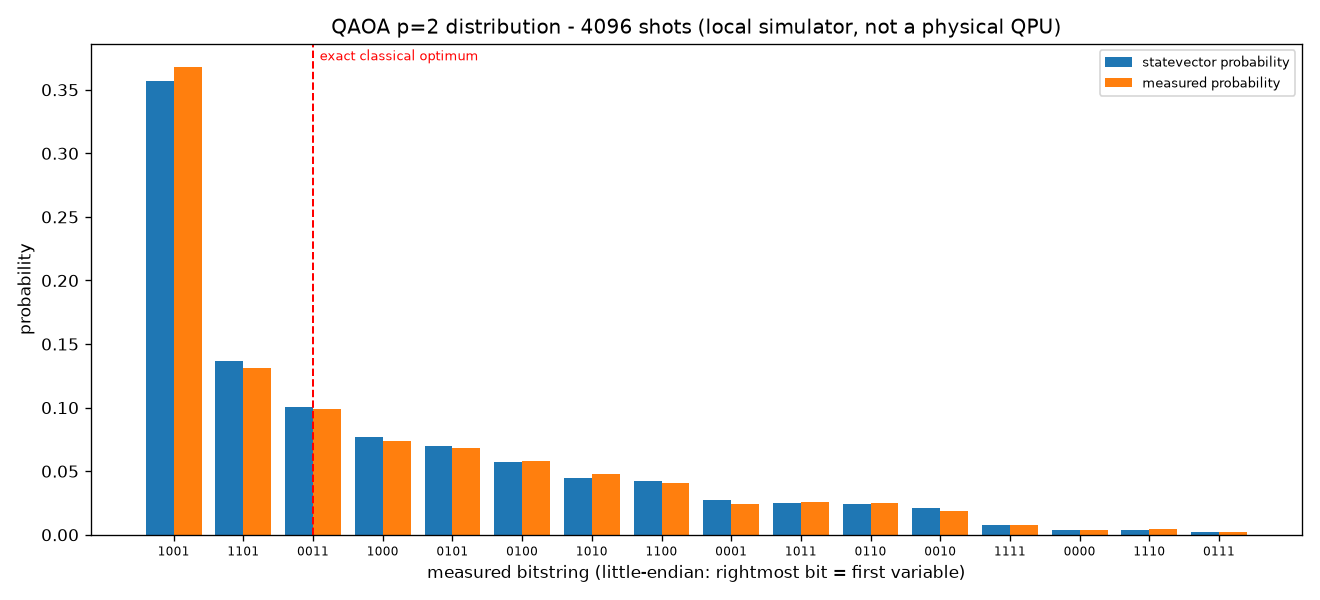


Structured report (q_flare_quantum_results\final_report.json):
{
  "Project": "Q-FLARE (Quantum-AI Flood Forecasting)",
  "Experiment": "QAOA rescue-resource allocation validation",
  "Synthetic data status": "SYNTHETIC demonstration data",
  "Data source": "SYNTHETIC (built-in demo)",
  "Number of qubits": 4,
  "QAOA depth": 2,
  "Number of shots": 4096,
  "Classical optimum": "0011",
  "QAOA solution": "0011",
  "Classical objective": 180.0,
  "QAOA objective": 180.0,
  "Energy gap": 0.0,
  "Objective gap": 0.0,
  "Feasibility": "FEASIBLE",
  "Optimal bitstring observed": "YES",
  "Automated tests": "13 passed, 0 failed",
  "Frontend modified": "NO",
  "Backend modified": "NO",
  "Existing Q-FLARE repository required": "NO",
  "Execution backend": "qiskit_aer.AerSimulator (local classical simulator)",
  "Physical quantum computer used": "NO",
  "Selected locations (classical)": [
    "L1 (Riverbank-A)",
    "L2 (Riverbank-B)"
  ],
  "Selected locations (QAOA)": [
    "L1 (Riverbank-

In [21]:
# --- OPTIONAL notebook helper: show the artifacts (not part of the engine) ---
def show_qflare_results():
    """Display the saved plot and print the saved report, if they exist."""
    import json

    directory = ensure_results_directory()
    try:
        from IPython.display import Image, display
    except ImportError:
        Image = display = None

    plot_path = directory / RESULT_FILES["distribution_png"]
    if plot_path.is_file() and Image is not None:
        print(f"Measurement distribution ({plot_path}):")
        display(Image(filename=str(plot_path)))
    else:
        print(f"[info] {plot_path.name} is not available in this runtime.")

    report_path = directory / RESULT_FILES["report_json"]
    if report_path.is_file():
        print()
        print(f"Structured report ({report_path}):")
        print(json.dumps(json.loads(report_path.read_text(encoding="utf-8")), indent=2))
    else:
        print(f"[info] {report_path.name} has not been written yet.")


show_qflare_results()